# SA_AutoLabel — Auto-Labeling Sentiment Dataset

Notebook ini melakukan **auto-labeling** pada ulasan yang belum berlabel menggunakan pre-trained model `mdhugol/indonesia-bert-sentiment-classification` (IndoBERT fine-tuned untuk review Indonesia, 3-class: positive/neutral/negative).

### Input

**Opsi A (Data asli):** `data/raw_review/Overall_All Data_for_Prediction.xlsx` (9,719 baris, 6 sheet)

**Opsi B (Desa wisata baru):** Taruh file CSV di `data/raw_review/additional/`. Format:
- `review` (wajib) — teks ulasan mentah
- `nama desa wisata` (opsional) — nama desa; jika tidak ada, diambil dari nama file
- `cleaned_review` (opsional) — teks bersih; jika tidak ada, auto-clean
- `label` (opsional) — label sentimen (0/1/2); jika tidak ada, auto-label oleh IndoBERT

### Output
`sentiment analysis/data/sentiment_labeled.csv` + 4 file JSON untuk dashboard

Label scheme: `0 = Negatif`, `1 = Positif`, `2 = Netral`

## 0. Setup

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline, AutoModelForSequenceClassification, AutoTokenizer

# Path setup — notebook berjalan dari 'sentiment analysis/'
BASE_DIR   = os.path.dirname(os.getcwd())  # TA_Notebook/
EXCEL_PATH = os.path.join(BASE_DIR, 'data', 'raw_review', 'Overall_All Data_for_Prediction.xlsx')
OUT_DIR    = os.path.join(os.getcwd(), 'data')
OUT_PATH   = os.path.join(OUT_DIR, 'sentiment_labeled.csv')

# Directory untuk CSV tambahan (desa wisata baru)
ADDITIONAL_DIR = os.path.join(BASE_DIR, 'data', 'raw_review', 'additional', 'cleaned')

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(ADDITIONAL_DIR, exist_ok=True)

SHEETS = ['Kampung_Blekok', 'Umbul_Ponggok', 'Pujon_Kidul',
          'Pentingsari', 'Penglipuran', 'Kete_Kesu']

# Label mapping dataset: 0=Negatif, 1=Positif, 2=Netral
LABEL_NAME = {0: 'Negatif', 1: 'Positif', 2: 'Netral'}
COLORS     = {'Positif': '#2ecc71', 'Negatif': '#e74c3c', 'Netral': '#3498db'}

print(f'EXCEL_PATH     : {EXCEL_PATH}')
 
print(f'ADDITIONAL_DIR : {ADDITIONAL_DIR}')
print(f'OUT_PATH       : {OUT_PATH}')

EXCEL_PATH     : d:\Kuliah\TA\TA_Notebook\data\raw_review\Overall_All Data_for_Prediction.xlsx
ADDITIONAL_DIR : d:\Kuliah\TA\TA_Notebook\data\raw_review\additional\cleaned
OUT_PATH       : d:\Kuliah\TA\TA_Notebook\sentiment analysis\data\sentiment_labeled.csv


## 1. Load Dataset

In [2]:
# ── Load dari Excel (data asli) ──
dfs = []
if os.path.exists(EXCEL_PATH):
    for sheet in SHEETS:
        df = pd.read_excel(EXCEL_PATH, sheet_name=sheet)
        df['sheet'] = sheet
        dfs.append(df)
    print(f'Loaded {sum(len(d) for d in dfs)} rows from Excel ({len(SHEETS)} sheets)')
else:
    print(f'Excel file not found at {EXCEL_PATH}, skipping')

# ── Load dari CSV tambahan (desa wisata baru) ──
# Format CSV: kolom "review" (wajib) + "nama desa wisata" (opsional, diambil dari nama file jika kosong)
# Kolom opsional: "cleaned_review", "label"
additional_csvs = sorted([f for f in os.listdir(ADDITIONAL_DIR)
                          if f.endswith('.csv') and '_full.csv' not in f])
if additional_csvs:
    print(f'\nFound {len(additional_csvs)} additional CSV(s):')
    for csv_file in additional_csvs:
        csv_path = os.path.join(ADDITIONAL_DIR, csv_file)
        csv_df = pd.read_csv(csv_path, encoding='utf-8')

        if 'review' not in csv_df.columns:
            print(f'  WARNING: {csv_file} missing "review" column, skipping')
            continue

        # Auto-fill village name if missing
        if 'nama desa wisata' not in csv_df.columns:
            name = csv_file.replace('_reviews', '').replace('.csv', '').replace('_', ' ')
            csv_df['nama desa wisata'] = name

        # Create cleaned_review if missing
        if 'cleaned_review' not in csv_df.columns:
            def basic_clean(text):
                text = str(text).lower().strip()
                text = re.sub(r'[^\w\s]', ' ', text)
                text = re.sub(r'\s+', ' ', text).strip()
                return text
            csv_df['cleaned_review'] = csv_df['review'].apply(basic_clean)

        # Mark all as unlabeled if no label column
        if 'label' not in csv_df.columns:
            csv_df['label'] = np.nan

        csv_df['sheet'] = csv_file
        dfs.append(csv_df)
        village = csv_df['nama desa wisata'].iloc[0]
        print(f'  {csv_file}: {len(csv_df)} rows ({village})')
else:
    print(f'\nNo additional CSVs found in {ADDITIONAL_DIR}')

all_df = pd.concat(dfs, ignore_index=True)

print(f'\nTotal rows: {len(all_df)}')
print(f'Columns   : {all_df.columns.tolist()}')
print()
print('Rows per desa wisata:')
print(all_df['nama desa wisata'].value_counts())

Loaded 9719 rows from Excel (6 sheets)

Found 32 additional CSV(s):
  buluh_cina_reviews.csv: 88 rows (Buluh Cina)
  danau_emtofe_reviews.csv: 100 rows (Danau Emtofe)
  danau_napabale_reviews.csv: 95 rows (Danau Napabale)
  danau_paisu_reviews.csv: 110 rows (Danau Paisu)
  desa_sade_reviews.csv: 90 rows (Desa Sade)
  desa_wisata_budo_reviews.csv: 99 rows (Desa Wisata Budo)
  desa_wisata_olele_reviews.csv: 124 rows (Desa Wisata Olele)
  desa_wisata_pampang_reviews.csv: 128 rows (Desa Wisata Pampang)
  desa_wisata_setulang_reviews.csv: 94 rows (Desa Wisata Setulang)
  desa_wisata_sungai_sekonyer_reviews.csv: 34 rows (Desa Wisata Sungai Sekonyer)
  desa_wisata_sungai_utik_reviews.csv: 52 rows (Desa Wisata Sungai Utik)
  desa_wisata_waerebo_reviews.csv: 103 rows (Desa Wisata Waerebo)
  gampong_nusa_reviews.csv: 49 rows (Gampong Nusa)
  kampung_ketupat_reviews.csv: 85 rows (Kampung Ketupat)
  kampung_marengo_baduy_reviews.csv: 131 rows (Kampung Marengo Baduy)
  kampung_naga_reviews.csv: 116

## 1b. Re-clean Semua `cleaned_review` dengan Pipeline Baru

Data dari Excel `Overall_All Data_for_Prediction.xlsx` di-pre-clean dengan pipeline lama yang mempertahankan tanda baca dan menerapkan stemming agresif. Cell ini menyamakan format dengan pipeline baru di `Clean_Reviews.ipynb`:

- **`cleaned_review`** = lowercase + emoji/URL/punct hapus + slang norm + light stopwords (TANPA stem). Dipakai untuk mdhugol, MTL, sample reviews di dashboard.
- **`cleaned_review_stemmed`** = ditambah Sastrawi stem. Dipakai untuk TF-IDF, opinion words, word cloud, bigram (analytics).

Untuk baris dari CSV tambahan (sudah lewat `Clean_Reviews.ipynb` versi baru), kolom `cleaned_review_stemmed` sudah ada → tidak diolah ulang. Untuk baris dari Excel, kedua kolom dibangun ulang dari kolom `review` (asli).

**WARNING — sinkronisasi**: function `clean_text` dan `stem_text` di sini HARUS sama persis dengan `Clean_Reviews.ipynb` cell 9. Kalau salah satunya diubah, ubah juga yang lain.

In [3]:
# Mirror dari Clean_Reviews.ipynb cell 9 — pastikan tetap sinkron jika diubah
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

_stemmer = StemmerFactory().create_stemmer()
_sastrawi_sw = set(StopWordRemoverFactory().get_stop_words())

# Slang lexicon (sama dengan Clean_Reviews)
_lex_path = os.path.join(BASE_DIR, 'data', 'raw', 'colloquial-indonesian-lexicon.csv')
_slang_df = pd.read_csv(_lex_path, usecols=['slang', 'formal'])
_slang_df = _slang_df.dropna().drop_duplicates(subset='slang')
_SLANG_DICT = dict(zip(_slang_df['slang'].str.lower().str.strip(),
                       _slang_df['formal'].str.lower().str.strip()))

# Light stopwords — TIDAK termasuk kata aspek generik (tempat/wisata/desa/lokasi/dll)
_EXTRA_SW = {
    'google', 'maps', 'map', 'review', 'reviews', 'bintang', 'star', 'stars',
    'ya', 'yah', 'dong', 'deh', 'sih', 'nih', 'tuh', 'nah', 'mah', 'loh', 'lah',
    'kok', 'kan', 'pun', 'kah', 'toh',
    'udah', 'udh', 'aja', 'doang', 'doank', 'seh', 'bgt', 'gtu', 'gitu', 'gini',
}
_LIGHT_SW = _sastrawi_sw | _EXTRA_SW

_EMOJI = re.compile(
    '['
    '\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF'
    '\U0001F1E0-\U0001F1FF\U00002702-\U000027B0\U000024C2-\U0001F251'
    '\U0001F900-\U0001F9FF\U0001FA00-\U0001FA6F\U0001FA70-\U0001FAFF'
    '\U00002600-\U000026FF\U0000FE00-\U0000FE0F\U0000200D'
    ']+', flags=re.UNICODE,
)


def _clean_text(text):
    text = str(text).lower()
    text = _EMOJI.sub(' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = ' '.join(_SLANG_DICT.get(w, w) for w in text.split())
    text = ' '.join(w for w in text.split() if w not in _LIGHT_SW)
    return text


def _stem_text(text):
    return _stemmer.stem(text)


# Identifikasi baris Excel vs CSV: CSV dari Clean_Reviews baru sudah punya
# 'cleaned_review_stemmed' yang non-null. Excel tidak punya kolom itu.
if 'cleaned_review_stemmed' not in all_df.columns:
    all_df['cleaned_review_stemmed'] = pd.NA

needs_reclean = all_df['cleaned_review_stemmed'].isna() | (all_df['cleaned_review_stemmed'] == '')
n_recl = int(needs_reclean.sum())
n_keep = len(all_df) - n_recl

print(f'Baris yang DIRECLEAN (sumber Excel) : {n_recl:,}')
print(f'Baris yang DIPERTAHANKAN (CSV baru) : {n_keep:,}')
print()

if n_recl > 0:
    print('Re-cleaning... ', end='', flush=True)
    src = all_df.loc[needs_reclean, 'review'].fillna('').astype(str)
    cleaned = src.apply(_clean_text)
    stemmed = cleaned.apply(_stem_text)
    all_df.loc[needs_reclean, 'cleaned_review']         = cleaned.values
    all_df.loc[needs_reclean, 'cleaned_review_stemmed'] = stemmed.values
    print('done')

    print('\nContoh re-clean (3 baris pertama dari Excel):')
    sample = all_df[needs_reclean].head(3)
    for _, r in sample.iterrows():
        print(f'\n  ASLI    : {str(r["review"])[:120]}')
        print(f'  cleaned : {str(r["cleaned_review"])[:120]}')
        print(f'  stemmed : {str(r["cleaned_review_stemmed"])[:120]}')

# Drop baris yang setelah cleaning kosong/terlalu pendek
before = len(all_df)
all_df = all_df[all_df['cleaned_review'].fillna('').apply(
    lambda x: len(str(x).split()) >= 1)].reset_index(drop=True)
print(f'\nDrop {before - len(all_df):,} baris dengan cleaned_review kosong (0 kata). '
      f'Sisa: {len(all_df):,}')


Baris yang DIRECLEAN (sumber Excel) : 9,864
Baris yang DIPERTAHANKAN (CSV baru) : 3,470

Re-cleaning... done

Contoh re-clean (3 baris pertama dari Excel):

  ASLI    : sebaiknya kampung blekok perbaiki seperti dulu lagi, kondisi rusak seperti sekarang ini tidak layak di tiket, jembatan k
  cleaned : kampung blekok perbaiki kondisi rusak layak tiket jembatan kayu rusak membahayakan pengunjung anak anak pengunjung membe
  stemmed : kampung blekok baik kondisi rusak layak tiket jembatan kayu rusak bahaya unjung anak anak unjung beli tiket jamin asuran

  ASLI    : sangat serru bermain dg anak2 sambil liat burung telkok yg banyak
  cleaned : serru bermain anak burung telkok
  stemmed : serru main anak burung telkok

  ASLI    : alam yg sejuk dan menyenang kan
  cleaned : alam sejuk menyenang
  stemmed : alam sejuk senang

Drop 56 baris dengan cleaned_review kosong (0 kata). Sisa: 13,278


## 2. Identifikasi Labeled vs Unlabeled

In [4]:
def is_unlabeled(val):
    """Cek apakah label kosong/invalid."""
    s = str(val).strip()
    return s in ['', 'nan', ' ', 'inference'] or pd.isna(val)

mask_unlabeled = all_df['label'].apply(is_unlabeled)

n_labeled   = (~mask_unlabeled).sum()
n_unlabeled = mask_unlabeled.sum()

print(f'Total     : {len(all_df)}')
print(f'Labeled   : {n_labeled} ({n_labeled/len(all_df)*100:.1f}%)')
print(f'Unlabeled : {n_unlabeled} ({n_unlabeled/len(all_df)*100:.1f}%)')
print()
print('Labeled per desa wisata:')
labeled_per_desa = all_df[~mask_unlabeled].groupby('nama desa wisata').size()
print(labeled_per_desa)

Total     : 13278
Labeled   : 2866 (21.6%)
Unlabeled : 10412 (78.4%)

Labeled per desa wisata:
nama desa wisata
kampung blekok    521
kete kesu         470
penglipuran       567
pentingsari       260
pujonkidul        570
umbul ponggok     478
dtype: int64


In [5]:
# Model: mdhugol/indonesia-bert-sentiment-classification
# LABEL_0=positive, LABEL_1=neutral, LABEL_2=negative
HF_LABEL_MAP = {
    'LABEL_0': 1,  # positive -> Positif
    'LABEL_1': 2,  # neutral  -> Netral
    'LABEL_2': 0,  # negative -> Negatif
}

pretrained = 'mdhugol/indonesia-bert-sentiment-classification'
model_sa = AutoModelForSequenceClassification.from_pretrained(pretrained)
tokenizer_sa = AutoTokenizer.from_pretrained(pretrained)
classifier = pipeline("sentiment-analysis", model=model_sa, tokenizer=tokenizer_sa)
print('Model loaded.')

# Test prediksi
test_reviews = [
    'tempatnya sangat indah dan menyenangkan',
    'pelayanan buruk dan mengecewakan',
    'biasa saja tidak ada yang spesial',
]
test_results = classifier(test_reviews)
print('Test prediksi:')
for rev, res in zip(test_reviews, test_results):
    label_num = HF_LABEL_MAP[res['label']]
    print(f'  [{LABEL_NAME[label_num]:7s} | score={res["score"]:.3f}] {rev}')

d:\miniconda3\envs\ta_nlp\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
d:\miniconda3\envs\ta_nlp\lib\site-packages\transformers\modeling_utils.py:446: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.s

Model loaded.
Test prediksi:
  [Positif | score=0.998] tempatnya sangat indah dan menyenangkan
  [Negatif | score=0.998] pelayanan buruk dan mengecewakan
  [Negatif | score=0.996] biasa saja tidak ada yang spesial


## 4. Auto-Label Baris yang Belum Berlabel

In [6]:
# Ambil teks yang belum berlabel
texts_to_label = all_df.loc[mask_unlabeled, 'cleaned_review'].fillna('').tolist()
texts_to_label = [t if t.strip() else 'tidak ada ulasan' for t in texts_to_label]

print(f'Melabel {len(texts_to_label)} baris...')

# Prediksi dalam batch
BATCH_SIZE = 32
results = classifier(
    texts_to_label,
    batch_size=BATCH_SIZE,
    truncation=True,
    max_length=128,
)

# Assign label
auto_labels = [HF_LABEL_MAP[r['label']] for r in results]
auto_scores = [r['score'] for r in results]

all_df.loc[mask_unlabeled, 'label']       = auto_labels
all_df.loc[mask_unlabeled, 'conf_score']  = auto_scores
all_df.loc[mask_unlabeled, 'label_source'] = 'auto'

# Label yang sudah ada (manual)
all_df.loc[~mask_unlabeled, 'label']       = pd.to_numeric(all_df.loc[~mask_unlabeled, 'label'], errors='coerce')
all_df.loc[~mask_unlabeled, 'conf_score']  = 1.0
all_df.loc[~mask_unlabeled, 'label_source'] = 'manual'

# Konversi label ke int
all_df['label'] = all_df['label'].astype(float).astype(int)

print('Auto-labeling selesai.')
print(f'\nDistribusi label (semua data):')
print(all_df['label'].map(LABEL_NAME).value_counts())

Melabel 10412 baris...
Auto-labeling selesai.

Distribusi label (semua data):
label
Positif    11464
Netral       978
Negatif      836
Name: count, dtype: int64


## 5. Verifikasi & Statistik

In [7]:
all_df['sentiment'] = all_df['label'].map(LABEL_NAME)

print('=== Distribusi per Desa Wisata ===')
pivot = all_df.groupby(['nama desa wisata', 'sentiment']).size().unstack(fill_value=0)
print(pivot)
print()

print('=== Manual vs Auto ===')
print(all_df['label_source'].value_counts())
print()

print('=== Distribusi Auto-label ===')
print(all_df[all_df['label_source']=='auto']['sentiment'].value_counts())
print()

print('=== Distribusi Manual ===')
print(all_df[all_df['label_source']=='manual']['sentiment'].value_counts())

=== Distribusi per Desa Wisata ===
sentiment                    Negatif  Netral  Positif
nama desa wisata                                     
Buluh Cina                         5       9       74
Danau Emtofe                      14       8       78
Danau Napabale                     8       4       83
Danau Paisu                        7       6       97
Desa Sade                          3      13       74
Desa Wisata Budo                   3       5       91
Desa Wisata Olele                  3       4      117
Desa Wisata Pampang                8      31       89
Desa Wisata Setulang               5      12       77
Desa Wisata Sungai Sekonyer        2      11       21
Desa Wisata Sungai Utik            2       7       43
Desa Wisata Waerebo                9      13       81
Gampong Nusa                       0       8       41
Kampung Ketupat                   18       7       60
Kampung Marengo Baduy             19      15       97
Kampung Naga                       5       9   

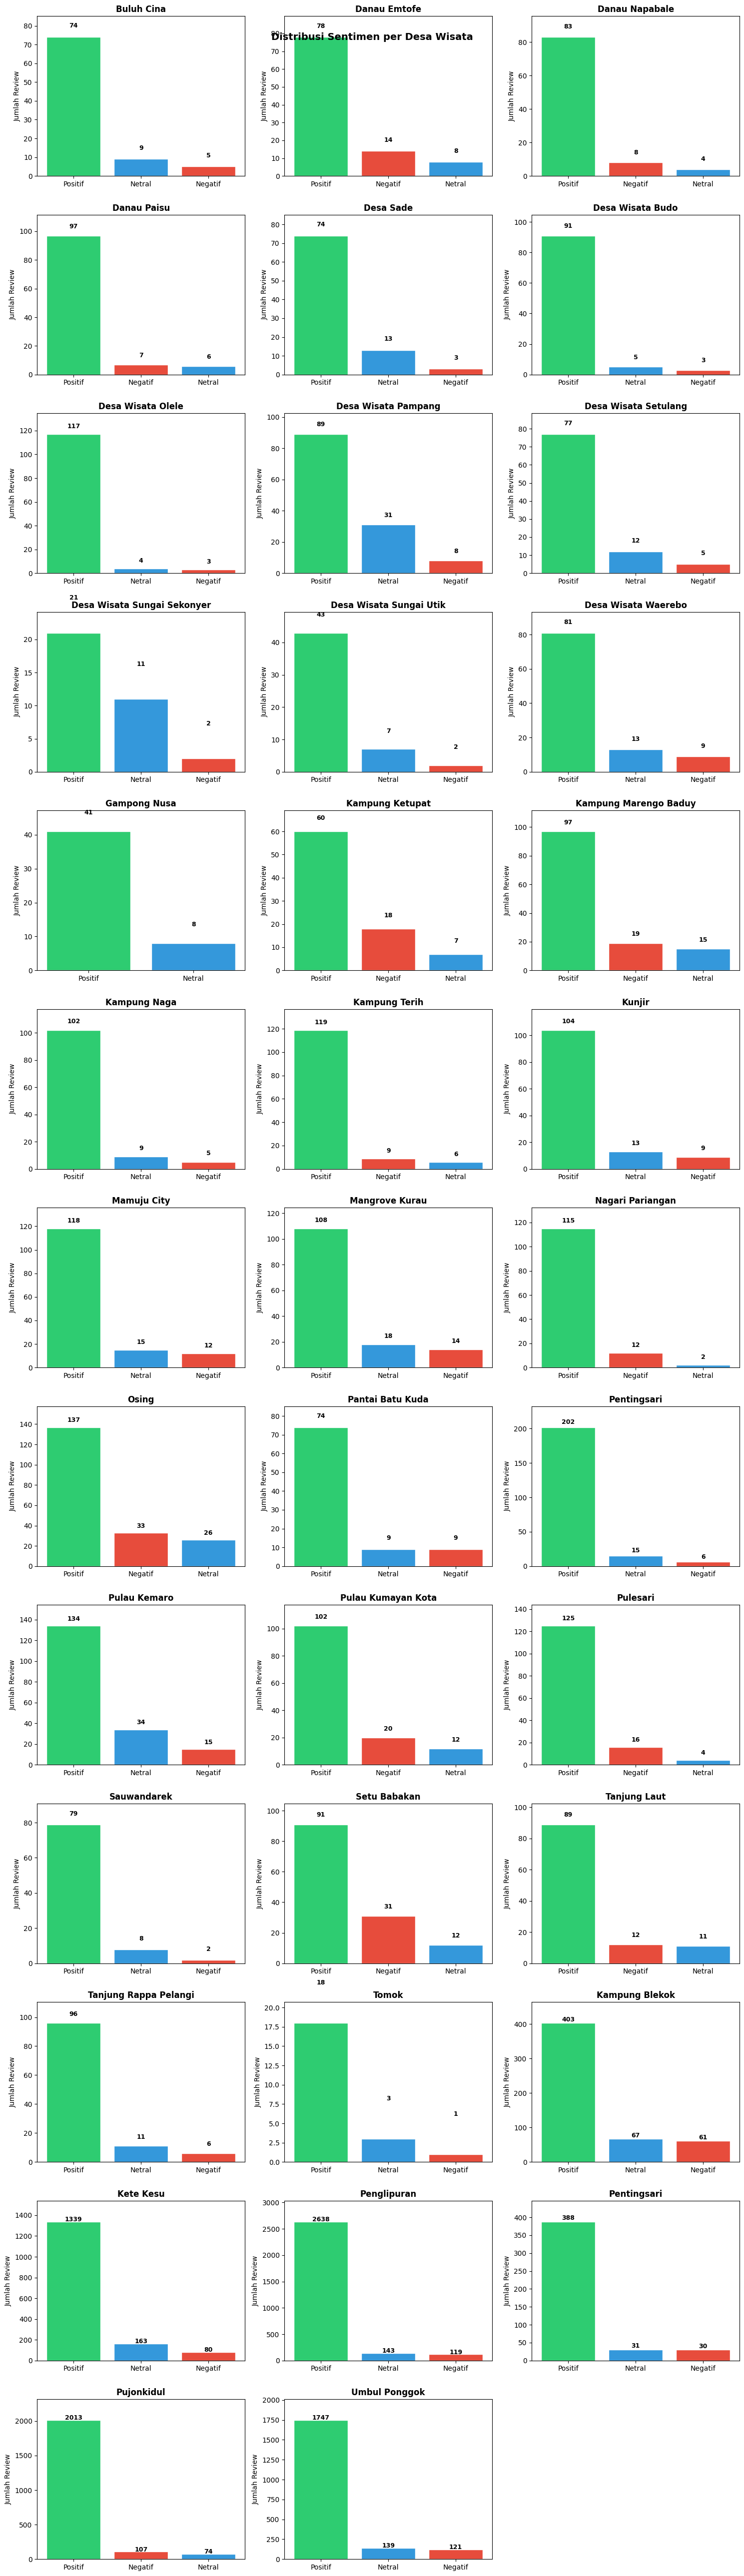

In [8]:
# Visualisasi distribusi sentimen per desa
import math
desa_list = sorted(all_df['nama desa wisata'].unique())
n_desa = len(desa_list)
ncols = 3
nrows = math.ceil(n_desa / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, desa in enumerate(desa_list):
    subset = all_df[all_df['nama desa wisata'] == desa]
    counts = subset['sentiment'].value_counts()
    bars = axes[i].bar(
        counts.index, counts.values,
        color=[COLORS.get(s, '#95a5a6') for s in counts.index],
        edgecolor='white'
    )
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                     str(val), ha='center', fontsize=9, fontweight='bold')
    axes[i].set_title(desa.title(), fontweight='bold')
    axes[i].set_ylabel('Jumlah Review')
    axes[i].set_ylim(0, counts.max() * 1.15)

# Hide unused subplots
for j in range(n_desa, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Sentimen per Desa Wisata', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

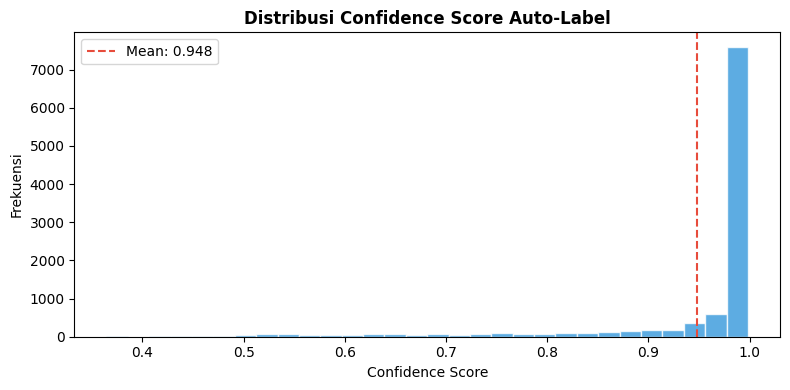

Confidence score rata-rata : 0.9481
Confidence score > 0.8     : 9425 (90.5%)
Confidence score > 0.9     : 8865 (85.1%)


In [9]:
# Confidence score distribution untuk auto-label
auto_data = all_df[all_df['label_source'] == 'auto']

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(auto_data['conf_score'], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
ax.axvline(auto_data['conf_score'].mean(), color='#e74c3c', linestyle='--',
           label=f'Mean: {auto_data["conf_score"].mean():.3f}')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi Confidence Score Auto-Label', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Confidence score rata-rata : {auto_data["conf_score"].mean():.4f}')
print(f'Confidence score > 0.8     : {(auto_data["conf_score"] > 0.8).sum()} ({(auto_data["conf_score"] > 0.8).mean()*100:.1f}%)')
print(f'Confidence score > 0.9     : {(auto_data["conf_score"] > 0.9).sum()} ({(auto_data["conf_score"] > 0.9).mean()*100:.1f}%)')

## 5b. Strip Residual Punctuation pada `cleaned_review`

Sebagian besar baris berasal dari `Overall_All Data_for_Prediction.xlsx` yang sudah dipre-clean dengan pipeline lama (tanda baca tidak dibuang). 
Cell ini menyamakan format dengan `Clean_Reviews.ipynb` step 4 (`re.sub(r'[^a-z\s]', ' ', text)`) supaya `cleaned_review` konsisten — tanpa koma/titik/dash — 
sebelum disimpan ke CSV dan dipakai untuk TF-IDF, MTL inference, dan dashboard.

In [10]:
# Strip residual punctuation/digits dari kedua kolom cleaned_review*
# (sejajar dgn Clean_Reviews.ipynb step 4)
def strip_residual_chars(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

for col in ['cleaned_review', 'cleaned_review_stemmed']:
    if col not in all_df.columns:
        continue
    before_dirty = all_df[col].fillna('').str.contains(r'[^a-z\s]', regex=True).sum()
    all_df[col] = all_df[col].fillna('').apply(strip_residual_chars)
    after_dirty = all_df[col].str.contains(r'[^a-z\s]', regex=True).sum()
    print(f'{col:25s} sebelum: {before_dirty:>5,} kotor, sesudah: {after_dirty}')

print('\nContoh (3 baris pertama):')
for _, r in all_df.head(3).iterrows():
    print(f'  cleaned : {str(r["cleaned_review"])[:90]}')
    print(f'  stemmed : {str(r.get("cleaned_review_stemmed", ""))[:90]}\n')


cleaned_review            sebelum:     5 kotor, sesudah: 0
cleaned_review_stemmed    sebelum:     1 kotor, sesudah: 0

Contoh (3 baris pertama):
  cleaned : kampung blekok perbaiki kondisi rusak layak tiket jembatan kayu rusak membahayakan pengunj
  stemmed : kampung blekok baik kondisi rusak layak tiket jembatan kayu rusak bahaya unjung anak anak 

  cleaned : serru bermain anak burung telkok
  stemmed : serru main anak burung telkok

  cleaned : alam sejuk menyenang
  stemmed : alam sejuk senang



## 6. Simpan Output

In [11]:
# Kolom yang disimpan untuk dashboard
out_cols = ['review', 'cleaned_review', 'cleaned_review_stemmed',
            'label', 'sentiment', 'label_source', 'conf_score', 'nama desa wisata', 'provinsi']
# Drop kolom optional yang tidak ada di all_df (graceful)
out_cols = [c for c in out_cols if c in all_df.columns]
out_df = all_df[out_cols].copy()

# Hapus baris tanpa review
out_df = out_df[out_df['cleaned_review'].notna() & (out_df['cleaned_review'].str.strip() != '')]

out_df.to_csv(OUT_PATH, index=False, encoding='utf-8')

print(f'Saved {len(out_df)} rows -> {OUT_PATH}')
print(f'Columns: {list(out_df.columns)}')
print()
print('Final distribusi:')
print(out_df['sentiment'].value_counts())
print()
print('Summary per desa wisata:')
summary = out_df.groupby(['nama desa wisata', 'sentiment']).size().unstack(fill_value=0)
summary['Total'] = summary.sum(axis=1)
print(summary)


Saved 13278 rows -> d:\Kuliah\TA\TA_Notebook\sentiment analysis\data\sentiment_labeled.csv
Columns: ['review', 'cleaned_review', 'cleaned_review_stemmed', 'label', 'sentiment', 'label_source', 'conf_score', 'nama desa wisata', 'provinsi']

Final distribusi:
sentiment
Positif    11464
Netral       978
Negatif      836
Name: count, dtype: int64

Summary per desa wisata:
sentiment                    Negatif  Netral  Positif  Total
nama desa wisata                                            
Buluh Cina                         5       9       74     88
Danau Emtofe                      14       8       78    100
Danau Napabale                     8       4       83     95
Danau Paisu                        7       6       97    110
Desa Sade                          3      13       74     90
Desa Wisata Budo                   3       5       91     99
Desa Wisata Olele                  3       4      117    124
Desa Wisata Pampang                8      31       89    128
Desa Wisata Setulan

## 7. NLP Pre-processing: Stopwords & Stemming

Setup stopwords Indonesia dan stemmer Sastrawi untuk analisis kata yang lebih bermakna.

In [12]:
# Install jika belum ada
import subprocess, sys
for pkg in ['Sastrawi', 'nltk']:
    try:
        __import__(pkg.lower() if pkg != 'Sastrawi' else 'Sastrawi')
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from collections import Counter
import re

# Sastrawi stemmer
stemmer = StemmerFactory().create_stemmer()
print('Sastrawi stemmer loaded.')
print(f'  Test: "pemandangan" -> "{stemmer.stem("pemandangan")}"')
print(f'  Test: "kebersihan" -> "{stemmer.stem("kebersihan")}"')


Sastrawi stemmer loaded.
  Test: "pemandangan" -> "pandang"
  Test: "kebersihan" -> "bersih"


In [13]:
# Indonesian stopwords HEAVY — khusus untuk analytics (TF-IDF, opinion words, word cloud)
# Termasuk kata aspek generik (tempat/wisata/desa/lokasi/dst) yang kalau ikut akan
# mendominasi keyword charts dan tidak informatif. Ini BERBEDA dengan stopwords
# untuk cleaning (di Clean_Reviews) yang lebih ringan supaya MTL bisa pakai kata-
# kata tersebut sebagai anchor aspek.
STOPWORDS_ID = {
    # Common function words
    'yang', 'di', 'ke', 'dari', 'dan', 'atau', 'untuk', 'dengan', 'pada',
    'dalam', 'sebagai', 'oleh', 'akan', 'ada', 'ini', 'itu', 'jadi', 'juga',
    'sudah', 'belum', 'sangat', 'sekali', 'tapi', 'tetapi', 'namun', 'karena',
    'kalau', 'jika', 'bila', 'kalo', 'agar', 'supaya', 'biar',
    'saya', 'aku', 'kami', 'kita', 'kamu', 'anda', 'dia', 'mereka',
    'kakak', 'adik', 'bapak', 'ibu', 'pak', 'bu', 'mas', 'mbak',
    # Particles & filler
    'ya', 'yah', 'dong', 'deh', 'sih', 'nih', 'tuh', 'nah', 'mah', 'loh', 'lah',
    'kok', 'kan', 'pun', 'kah', 'toh', 'sajalah', 'aja', 'saja',
    'udah', 'udh', 'doang', 'doank', 'seh', 'bgt', 'gtu', 'gitu', 'gini',
    'banget', 'banget',
    # Generic aspect carriers — too generic for keyword analytics
    'tempat', 'tempatnya', 'wisata', 'desa', 'lokasi', 'pergi', 'datang',
    'kunjungi', 'objek', 'destinasi', 'daerah', 'area', 'kawasan', 'spot',
    # Visit / experience generic verbs
    'kunjungan', 'kesini', 'kesana', 'main', 'mainnya', 'liburan',
    # Time-related generic
    'kemarin', 'tadi', 'sekarang', 'nanti', 'dulu', 'lagi', 'masih',
    # Numerals / quantity that aren't useful
    'satu', 'dua', 'tiga', 'banyak', 'sedikit', 'sebagian',
    # Misc generic
    'google', 'maps', 'map', 'review', 'reviews', 'bintang', 'star', 'stars',
    'rating', 'admin', 'pemilik',
}
print(f'STOPWORDS_ID (heavy, untuk analytics): {len(STOPWORDS_ID)} kata')


STOPWORDS_ID (heavy, untuk analytics): 122 kata


## 8. Deteksi Aspek / Topik per Review

Kategorisasi aspek yang dibicarakan pengunjung menggunakan keyword matching.
Setiap review bisa memiliki >1 aspek.

In [14]:
# Definisi keyword per kategori aspek
ASPECT_KEYWORDS = {
    'Pemandangan & Alam': [
        'pemandangan', 'alam', 'sawah', 'gunung', 'sungai', 'mangrove',
        'pantai', 'air terjun', 'pohon', 'hutan', 'danau', 'laut',
        'bukit', 'taman', 'kebun', 'persawahan', 'terasering',
        'sunrise', 'sunset', 'view', 'landscape',
    ],
    'Kebersihan': [
        'bersih', 'kotor', 'sampah', 'toilet', 'kamar mandi', 'wc',
        'kebersihan', 'rapi', 'jorok', 'kumuh', 'terawat',
    ],
    'Pelayanan': [
        'pelayanan', 'ramah', 'warga', 'masyarakat', 'guide',
        'pengelola', 'staff', 'petugas', 'penjaga',
        'pelayan', 'layanan', 'sambutan',
    ],
    'Fasilitas': [
        'fasilitas', 'parkir', 'jembatan', 'gazebo', 'wifi',
        'spot foto', 'kolam', 'wahana', 'mushola',
        'playground', 'ayunan', 'gardu pandang', 'homestay',
        'penginapan', 'villa', 'cottage', 'outbound',
    ],
    'Harga & Tiket': [
        'harga', 'tiket', 'murah', 'mahal', 'biaya', 'gratis',
        'bayar', 'tarif', 'retribusi', 'terjangkau', 'worth',
    ],
    'Kuliner': [
        'makanan', 'minuman', 'kopi', 'warung', 'restoran', 'kuliner',
        'menu', 'cafe', 'makan', 'minum', 'jajanan', 'oleh-oleh',
        'souvenir', 'snack', 'kedai', 'rumah makan',
    ],
    'Suasana': [
        'suasana', 'tenang', 'sejuk', 'nyaman', 'asri', 'adem',
        'damai', 'segar', 'teduh', 'dingin', 'udara',
        'santai', 'rileks',
    ],
    'Akses & Lokasi': [
        'lokasi', 'akses', 'jarak', 'jauh', 'dekat', 'strategis',
        'jalan', 'rute', 'transportasi', 'kendaraan',
        'motor', 'mobil', 'bus', 'ojek',
    ],
    'Budaya & Tradisi': [
        'budaya', 'adat', 'tradisi', 'rumah adat', 'upacara',
        'kesenian', 'tari', 'musik', 'gamelan', 'batik',
        'kerajinan', 'sejarah', 'heritage',
    ],
}

def detect_aspects(text):
    """Deteksi aspek dari teks review. Return list of matched categories."""
    text_lower = str(text).lower()
    found = []
    for category, keywords in ASPECT_KEYWORDS.items():
        for kw in keywords:
            if kw in text_lower:
                found.append(category)
                break
    return found if found else ['Lainnya']

# Apply ke seluruh dataset
out_df['aspects'] = out_df['cleaned_review'].apply(detect_aspects)

# Statistik
all_aspects = [a for alist in out_df['aspects'] for a in alist]
aspect_counts = Counter(all_aspects)
print('Distribusi aspek (total mention):')
for asp, cnt in aspect_counts.most_common():
    pct = cnt / len(out_df) * 100
    print(f'  {asp:25s} {cnt:>6,} ({pct:.1f}%)')


Distribusi aspek (total mention):
  Lainnya                    3,909 (29.4%)
  Suasana                    3,454 (26.0%)
  Pemandangan & Alam         2,832 (21.3%)
  Kebersihan                 2,627 (19.8%)
  Harga & Tiket              1,880 (14.2%)
  Budaya & Tradisi           1,746 (13.1%)
  Kuliner                    1,742 (13.1%)
  Pelayanan                  1,639 (12.3%)
  Fasilitas                  1,605 (12.1%)
  Akses & Lokasi             1,483 (11.2%)


## 8b. Load MTL Model (Hierarchical Multi-Task ABSA)

Load model MTL terbaik (`best_model.pt`, F1=0.7410) untuk inferensi token-level BIEOS.
Model ini akan dipakai di Section 8c untuk mendapatkan sentimen per-aspek yang lebih akurat
dibanding pendekatan sentence-level dari mdhugol.

In [15]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer
from torchcrf import CRF
import json as _json

# ── Config ──
MTL_MODEL_NAME  = 'indobenchmark/indobert-large-p2'
MTL_MODEL_PATH  = os.path.join(BASE_DIR, 'models', 'best_model.pt')
BIEOS_DATA_PATH = os.path.join(BASE_DIR, 'data', 'processed', 'train_data_bieos.json')

ate_labels   = ['O', 'B', 'I', 'E', 'S']
bieos_labels = ['O', 'B-NEG', 'B-NEU', 'B-POS', 'E-NEG', 'E-NEU', 'E-POS',
                'I-NEG', 'I-NEU', 'I-POS', 'S-NEG', 'S-NEU', 'S-POS']
ate_label2id   = {l: i for i, l in enumerate(ate_labels)}
bieos_id2label = {i: l for i, l in enumerate(bieos_labels)}
MTL_PROJ_DIM   = 256

device_mtl = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device_mtl}')

# Bebaskan VRAM dari mdhugol sebelum load model besar
try:
    del classifier, model_sa, tokenizer_sa
    import gc; gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print('mdhugol freed from memory.')
except NameError:
    pass


# ── Definisi Model (identik dengan NB 03) ──
class CrossAttentionASD(nn.Module):
    def __init__(self, dim, max_relative_position=20):
        super().__init__()
        self.max_rel_pos    = max_relative_position
        self.pos_embedding  = nn.Embedding(2 * max_relative_position + 1, dim)
        self.W_ae  = nn.Linear(dim, dim, bias=False)
        self.W_sl  = nn.Linear(dim, dim, bias=False)
        self.W_pos = nn.Linear(dim, dim, bias=False)
        self.bias  = nn.Parameter(torch.zeros(dim))
        self.w_s   = nn.Linear(dim, 1, bias=False)

    def forward(self, h_ae, h_sl, mask=None):
        batch, seq_len, dim = h_ae.shape
        pos     = torch.arange(seq_len, device=h_ae.device)
        rel_pos = (pos.unsqueeze(0) - pos.unsqueeze(1)).clamp(
            -self.max_rel_pos, self.max_rel_pos) + self.max_rel_pos
        p_ij     = self.pos_embedding(rel_pos)
        combined = (self.W_ae(h_ae).unsqueeze(2)
                    + self.W_sl(h_sl).unsqueeze(1)
                    + self.W_pos(p_ij).unsqueeze(0)
                    + self.bias)
        scores = self.w_s(torch.tanh(combined)).squeeze(-1)
        if mask is not None:
            scores = scores.masked_fill(~mask.unsqueeze(1), float('-inf'))
        return torch.bmm(torch.softmax(scores, dim=-1), h_sl)


class HierarchicalMultiTaskABSA(nn.Module):
    def __init__(self, model_name, num_ate, num_sld, num_asd, num_final,
                 proj_dim=256, dropout=0.1, max_relative_position=20, **kwargs):
        super().__init__()
        self.num_ate = num_ate
        self.bert    = AutoModel.from_pretrained(model_name, low_cpu_mem_usage=True)
        bert_dim = self.bert.config.hidden_size
        self.ate_proj       = nn.Sequential(nn.Linear(bert_dim + num_ate, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.ate_classifier = nn.Linear(proj_dim, num_ate)
        self.sld_proj       = nn.Sequential(nn.Linear(bert_dim, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.sld_classifier = nn.Linear(proj_dim, num_sld)
        self.cross_attention = CrossAttentionASD(proj_dim, max_relative_position)
        self.asd_classifier  = nn.Linear(proj_dim, num_asd)
        self.final_proj      = nn.Sequential(nn.Linear(proj_dim * 2, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.final_emission  = nn.Linear(proj_dim, num_final)
        self.crf     = CRF(num_final, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids, attention_mask, prior_probs=None, **kwargs):
        h = self.dropout(
            self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state)
        if prior_probs is None:
            prior_probs = torch.zeros(*h.shape[:-1], self.num_ate, device=h.device)
        h_ae  = self.ate_proj(torch.cat([h, prior_probs], dim=-1))
        h_sl  = self.sld_proj(h)
        mask  = attention_mask.bool()
        h_sd  = self.cross_attention(h_ae, h_sl, mask=mask)
        emissions = self.final_emission(self.final_proj(torch.cat([h_ae, h_sd], dim=-1)))
        return {'emissions': emissions}

    def decode(self, emissions, attention_mask):
        return self.crf.decode(emissions.float(), mask=attention_mask.bool())


# ── Build word_prior dari data training ──
print('Building word_prior ...')
with open(BIEOS_DATA_PATH, 'r', encoding='utf-8') as f:
    bieos_train = _json.load(f)

default_prior = [1.0] + [0.0] * (len(ate_labels) - 1)
word_ate_freq = {}
for sample in bieos_train:
    for tok, lab in zip(sample['tokens'], sample['labels']):
        t = tok.lower()
        if t not in word_ate_freq:
            word_ate_freq[t] = [0] * len(ate_labels)
        prefix = lab.split('-')[0] if lab != 'O' else 'O'
        word_ate_freq[t][ate_label2id[prefix]] += 1

word_prior = {
    w: [c / sum(counts) for c in counts] if sum(counts) > 0 else default_prior
    for w, counts in word_ate_freq.items()
}
print(f'word_prior: {len(word_prior)} unique words')

# ── Load tokenizer & model ──
print(f'\nLoading MTL model: {MTL_MODEL_PATH}')
tokenizer_mtl = AutoTokenizer.from_pretrained(MTL_MODEL_NAME)
model_mtl = HierarchicalMultiTaskABSA(
    model_name=MTL_MODEL_NAME,
    num_ate=len(ate_labels), num_sld=3, num_asd=4,
    num_final=len(bieos_labels),
    proj_dim=MTL_PROJ_DIM, dropout=0.1, max_relative_position=20,
).to(device_mtl)

# strict=False: aman karena key yang missing (position_ids) adalah buffer
# positional encoding bawaan transformers baru, bukan parameter yang dilatih
missing, unexpected = model_mtl.load_state_dict(
    torch.load(MTL_MODEL_PATH, map_location=device_mtl, weights_only=True),
    strict=False,
)
if missing:
    print(f'Missing keys (ignored): {missing}')
if unexpected:
    print(f'Unexpected keys: {unexpected}')

model_mtl.eval()
print('MTL model ready.')

Device: cuda
mdhugol freed from memory.
Building word_prior ...
word_prior: 4682 unique words

Loading MTL model: d:\Kuliah\TA\TA_Notebook\models\best_model.pt


d:\miniconda3\envs\ta_nlp\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
d:\miniconda3\envs\ta_nlp\lib\site-packages\transformers\modeling_utils.py:446: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.s

Missing keys (ignored): ['bert.embeddings.position_ids']
MTL model ready.


## 8c. Inferensi MTL — Sentimen Per-Aspek

Untuk setiap review, jalankan MTL model dan ekstrak span aspek beserta sentimennya (BIEOS token-level).
Span di-map ke kategori via `ASPECT_KEYWORDS` yang sama. Hasilnya disimpan di kolom `mtl_sentiments`
untuk digunakan di Section 10 menggantikan sentence-level sentiment dari mdhugol.

In [16]:
from tqdm.auto import tqdm
from collections import Counter

MTL_SENT_MAP   = {'POS': 'Positif', 'NEG': 'Negatif', 'NEU': 'Netral'}
MTL_BATCH_SIZE = 16


def extract_bieos_spans(word_tokens, pred_labels):
    """Extract list of (span_text, sentiment) from word-level BIEOS predictions."""
    spans = []
    i = 0
    while i < len(pred_labels):
        lbl = pred_labels[i]
        if lbl == 'O' or '-' not in lbl:
            i += 1
            continue
        prefix, sentiment = lbl.split('-', 1)
        if prefix == 'S':
            spans.append((word_tokens[i], sentiment))
            i += 1
        elif prefix == 'B':
            span_toks = [word_tokens[i]]
            j = i + 1
            while j < len(pred_labels):
                nlbl = pred_labels[j]
                if '-' not in nlbl:
                    break
                nprefix, _ = nlbl.split('-', 1)
                if nprefix in ('I', 'E'):
                    span_toks.append(word_tokens[j])
                    j += 1
                    if nprefix == 'E':
                        break
                else:
                    break
            spans.append((' '.join(span_toks), sentiment))
            i = j
        else:
            i += 1
    return spans


def span_to_category(span_text):
    """Map extracted span to aspect category via keyword matching. Returns None if no match."""
    span_lower = span_text.lower()
    for category, keywords in ASPECT_KEYWORDS.items():
        for kw in keywords:
            if kw in span_lower:
                return category
    return None


def run_mtl_batch(texts, model, tokenizer, word_prior, device,
                  batch_size=16, max_length=128):
    """
    Run MTL inference on a list of cleaned_review strings.
    Returns list of dicts: {category: 'Positif'|'Negatif'|'Netral'}
    Only categories where the model extracted at least one aspect span are included.
    """
    default_p = [1.0] + [0.0] * (len(ate_labels) - 1)
    results = []

    for start in tqdm(range(0, len(texts), batch_size), desc='MTL inference', unit='batch'):
        batch_texts = texts[start:start + batch_size]
        batch_words = [str(t).lower().split() for t in batch_texts]

        enc = tokenizer(
            batch_words,
            is_split_into_words=True,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )

        batch_prior = []
        for b, words in enumerate(batch_words):
            word_ids  = enc.word_ids(batch_index=b)
            prior_seq = [
                word_prior.get(words[wid], default_p) if (wid is not None and wid < len(words)) else default_p
                for wid in word_ids
            ]
            batch_prior.append(prior_seq)

        input_ids      = enc['input_ids'].to(device)
        attention_mask = enc['attention_mask'].to(device)
        prior_probs    = torch.tensor(batch_prior, dtype=torch.float).to(device)

        with torch.no_grad():
            out   = model(input_ids=input_ids, attention_mask=attention_mask,
                          prior_probs=prior_probs)
            preds = model.decode(out['emissions'], attention_mask)

        for b, words in enumerate(batch_words):
            word_ids = enc.word_ids(batch_index=b)
            pred_ids = preds[b]

            word_pred = {}
            for pos, wid in enumerate(word_ids):
                if wid is not None and wid < len(words) and wid not in word_pred:
                    word_pred[wid] = bieos_id2label[pred_ids[pos]]
            word_labels = [word_pred.get(i, 'O') for i in range(len(words))]

            spans = extract_bieos_spans(words, word_labels)

            cat_votes = {}
            for span_text, sentiment in spans:
                cat = span_to_category(span_text)
                if cat:
                    cat_votes.setdefault(cat, []).append(MTL_SENT_MAP[sentiment])

            resolved = {
                cat: Counter(sents).most_common(1)[0][0]
                for cat, sents in cat_votes.items()
            }
            results.append(resolved)

    return results


# ── Run inference ──
print(f'Running MTL inference on {len(out_df)} reviews...')
texts_for_mtl = out_df['cleaned_review'].fillna('').tolist()
mtl_results   = run_mtl_batch(
    texts_for_mtl, model_mtl, tokenizer_mtl, word_prior,
    device_mtl, batch_size=MTL_BATCH_SIZE,
)
out_df['mtl_sentiments'] = mtl_results

# ── Coverage stats ──
n_with_spans = sum(1 for r in mtl_results if r)
print(f'\nCoverage: {n_with_spans}/{len(mtl_results)} reviews '
      f'punya >=1 aspect span ({n_with_spans/len(mtl_results)*100:.1f}%)')

cat_counts = Counter()
for r in mtl_results:
    cat_counts.update(r.keys())
print('\nKategori yang diekstrak MTL:')
for cat, cnt in cat_counts.most_common():
    print(f'  {cat:25s}: {cnt:,}')

# Bebaskan VRAM
del model_mtl
import gc; gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('\nMTL model freed from memory.')

Running MTL inference on 13278 reviews...


MTL inference:   0%|          | 0/830 [00:00<?, ?batch/s]


Coverage: 5571/13278 reviews punya >=1 aspect span (42.0%)

Kategori yang diekstrak MTL:
  Pemandangan & Alam       : 1,573
  Fasilitas                : 1,179
  Harga & Tiket            : 876
  Suasana                  : 860
  Akses & Lokasi           : 715
  Kuliner                  : 707
  Budaya & Tradisi         : 662
  Pelayanan                : 579
  Kebersihan               : 325

MTL model freed from memory.


## 9. TF-IDF Keyword Extraction

Ekstraksi kata kunci paling distinktif per (desa, sentimen) menggunakan TF-IDF.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Pakai cleaned_review_stemmed supaya variasi imbuhan ('pemandangan',
# 'pemandangannya') di-collapse ke kata dasar — TF-IDF jadi lebih akurat.
TFIDF_TEXT_COL = ('cleaned_review_stemmed' if 'cleaned_review_stemmed' in out_df.columns
                  else 'cleaned_review')
print(f'TF-IDF source column: {TFIDF_TEXT_COL}')

desa_list = sorted(out_df['nama desa wisata'].dropna().unique().tolist())
tfidf_results = {}

for desa in desa_list + ['Semua']:
    for sentiment in ['Positif', 'Negatif', 'Netral']:
        if desa == 'Semua':
            subset = out_df[out_df['sentiment'] == sentiment]
        else:
            subset = out_df[(out_df['nama desa wisata'] == desa) &
                            (out_df['sentiment'] == sentiment)]

        texts = subset[TFIDF_TEXT_COL].dropna().tolist()
        if len(texts) < 5:
            continue

        try:
            tfidf = TfidfVectorizer(
                max_features=500,
                stop_words=list(STOPWORDS_ID),
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
            )
            X = tfidf.fit_transform(texts)
            mean_scores = X.mean(axis=0).A1
            top_idx = mean_scores.argsort()[::-1][:15]
            features = tfidf.get_feature_names_out()
            keywords = [[features[i], round(float(mean_scores[i]), 4)] for i in top_idx]
            tfidf_results[f'{desa}_{sentiment}'] = keywords
        except ValueError:
            continue

import json as _json
tfidf_path = os.path.join(os.path.dirname(OUT_PATH), 'tfidf_keywords.json')
with open(tfidf_path, 'w', encoding='utf-8') as f:
    _json.dump(tfidf_results, f, ensure_ascii=False, indent=2)
print(f'Saved TF-IDF keywords -> {tfidf_path}')
print(f'Total combinations: {len(tfidf_results)}')

for key in list(tfidf_results.keys())[:3]:
    print(f'\n{key}:')
    for word, score in tfidf_results[key][:5]:
        print(f'  {word:25s} {score:.4f}')


TF-IDF source column: cleaned_review_stemmed
Saved TF-IDF keywords -> d:\Kuliah\TA\TA_Notebook\sentiment analysis\data\tfidf_keywords.json
Total combinations: 102

Buluh Cina_Positif:
  gajah                     0.0786
  asri                      0.0722
  alam                      0.0638
  adem                      0.0555
  bagus                     0.0492

Buluh Cina_Negatif:
  gajah                     0.4661
  alam                      0.2539
  timbang                   0.1834
  kelola                    0.1834
  moga                      0.1834

Buluh Cina_Netral:
  gajah                     0.2040
  butuh                     0.1479
  kunjung                   0.1479
  alam                      0.1479
  ribu                      0.1312


## 10. Agregasi Aspek & Insight Generation

Menghasilkan file JSON ringkasan untuk dashboard: aspek summary & insight per desa.

In [18]:
import json as _json

# ── 10a. Aspect Summary (MTL-enhanced) ──
# Untuk tiap review x aspek:
#   - Jika MTL punya span yang cocok ke kategori tsb -> pakai sentimen MTL
#   - Jika tidak ada span MTL -> fallback ke sentence-level sentimen mdhugol
exploded = out_df.explode('aspects').copy()
exploded['effective_sentiment'] = exploded.apply(
    lambda row: row['mtl_sentiments'].get(row['aspects'], row['sentiment']),
    axis=1,
)

aspect_summary = {}
for desa in desa_list + ['Semua']:
    if desa == 'Semua':
        sub = exploded
    else:
        sub = exploded[exploded['nama desa wisata'] == desa]

    desa_data = {}
    for aspect in list(ASPECT_KEYWORDS.keys()) + ['Lainnya']:
        asp_sub = sub[sub['aspects'] == aspect]
        if len(asp_sub) == 0:
            continue
        sent_counts = asp_sub['effective_sentiment'].value_counts().to_dict()
        total = len(asp_sub)
        desa_data[aspect] = {
            'total':   total,
            'Positif': sent_counts.get('Positif', 0),
            'Negatif': sent_counts.get('Negatif', 0),
            'Netral':  sent_counts.get('Netral',  0),
            'positivity_rate': round(sent_counts.get('Positif', 0) / total * 100, 1) if total > 0 else 0,
        }
    aspect_summary[desa] = desa_data

asp_path = os.path.join(os.path.dirname(OUT_PATH), 'aspect_summary.json')
with open(asp_path, 'w', encoding='utf-8') as f:
    _json.dump(aspect_summary, f, ensure_ascii=False, indent=2)
print(f'Saved aspect summary (MTL-enhanced) -> {asp_path}')

# ── Coverage: berapa pairs pakai MTL vs fallback ──
non_lainnya = exploded[exploded['aspects'] != 'Lainnya']
mtl_hit = non_lainnya.apply(lambda row: row['aspects'] in row['mtl_sentiments'], axis=1)
print(f'\nMTL signal dipakai  : {mtl_hit.sum():,} / {len(mtl_hit):,} '
      f'({mtl_hit.mean()*100:.1f}%) aspect-review pairs')
print(f'Fallback ke mdhugol : {(~mtl_hit).sum():,} pairs')

print('\nSemua Desa Wisata (MTL-enhanced):')
for asp, data in sorted(aspect_summary['Semua'].items(), key=lambda x: x[1]['total'], reverse=True):
    print(f'  {asp:25s}  total={data["total"]:>5,}  '
          f'pos={data["Positif"]:>5,}  neg={data["Negatif"]:>4,}  '
          f'pos_rate={data["positivity_rate"]:>5.1f}%')

Saved aspect summary (MTL-enhanced) -> d:\Kuliah\TA\TA_Notebook\sentiment analysis\data\aspect_summary.json

MTL signal dipakai  : 7,476 / 19,008 (39.3%) aspect-review pairs
Fallback ke mdhugol : 11,532 pairs

Semua Desa Wisata (MTL-enhanced):
  Lainnya                    total=3,909  pos=3,314  neg= 276  pos_rate= 84.8%
  Suasana                    total=3,454  pos=3,308  neg=  56  pos_rate= 95.8%
  Pemandangan & Alam         total=2,832  pos=2,444  neg= 151  pos_rate= 86.3%
  Kebersihan                 total=2,627  pos=2,298  neg= 207  pos_rate= 87.5%
  Harga & Tiket              total=1,880  pos=1,400  neg= 170  pos_rate= 74.5%
  Budaya & Tradisi           total=1,746  pos=1,378  neg=  70  pos_rate= 78.9%
  Kuliner                    total=1,742  pos=1,441  neg= 133  pos_rate= 82.7%
  Pelayanan                  total=1,639  pos=1,448  neg=  83  pos_rate= 88.3%
  Fasilitas                  total=1,605  pos=1,089  neg= 215  pos_rate= 67.9%
  Akses & Lokasi             total=1,483  pos

## 10b. Audit: Span MTL yang Tidak Ter-mapping ke Kategori

Tampilkan kata yang sering muncul di review dengan MTL signal tapi tidak cocok ke keyword manapun di `ASPECT_KEYWORDS`.
Gunakan output ini untuk mempertimbangkan penambahan keyword baru.

In [19]:
# Kumpulkan kata-kata yang sering muncul di review ber-MTL tapi tidak cocok ke ASPECT_KEYWORDS
unmatched = Counter()

for text, mtl_dict in zip(out_df['cleaned_review'].fillna(''), out_df['mtl_sentiments']):
    if not mtl_dict:
        continue
    for word in str(text).lower().split():
        if word in STOPWORDS_ID or len(word) <= 3:
            continue
        if span_to_category(word) is None:
            unmatched[word] += 1

MIN_FREQ   = 10
candidates = {w: c for w, c in unmatched.items() if c >= MIN_FREQ}

print(f'Kata yang sering muncul di review ber-MTL tapi TIDAK masuk ASPECT_KEYWORDS:')
print(f'(min freq={MIN_FREQ}, total kandidat={len(candidates)})')
print()
for word, count in sorted(candidates.items(), key=lambda x: x[1], reverse=True)[:60]:
    print(f'  {word:20s} : {count:,}x')

print()
print('>> Pertimbangkan menambah kata di atas ke ASPECT_KEYWORDS yang relevan,'  )
print('   lalu re-run dari Section 8 untuk refresh aspect_summary.json.')

Kata yang sering muncul di review ber-MTL tapi TIDAK masuk ASPECT_KEYWORDS:
(min freq=10, total kandidat=829)

  bagus                : 1,347x
  foto                 : 785x
  rumah                : 630x
  indah                : 599x
  ribu                 : 507x
  bali                 : 444x
  cocok                : 406x
  anak                 : 398x
  toraja               : 364x
  keluarga             : 341x
  khas                 : 306x
  salah                : 281x
  ikan                 : 270x
  pengunjung           : 267x
  keren                : 264x
  sewa                 : 262x
  luas                 : 260x
  baju                 : 254x
  menarik              : 245x
  lumayan              : 242x
  menikmati            : 203x
  airnya               : 191x
  kota                 : 189x
  kampung              : 179x
  lokal                : 177x
  tersedia             : 171x
  berkunjung           : 167x
  seru                 : 167x
  ramai                : 166x
  berenang       

### 10c. Auto-Extend ASPECT_KEYWORDS dari Audit

Cell ini mengambil top kandidat dari audit 10b dan auto-assign ke kategori `ASPECT_KEYWORDS` yang paling cocok berdasarkan word similarity (substring match terhadap keyword existing). Kandidat yang tidak match ke kategori manapun ditampilkan untuk review manual.

**Threshold**: hanya kandidat dengan frekuensi >= `MIN_FREQ_AUTO` yang di-auto-assign supaya kata yang muncul sangat jarang tidak mencemari kategori.

In [20]:
# Auto-extend ASPECT_KEYWORDS dari hasil audit cell 10b (variabel `candidates`)
MIN_FREQ_AUTO = 15  # threshold frekuensi minimum untuk auto-assign

if 'candidates' not in dir():
    print('WARNING: variabel `candidates` belum ada. Jalankan cell audit 10b dulu.')
else:
    # Build kata index dari ASPECT_KEYWORDS untuk similarity check
    aspect_word_set = {asp: set(kws) for asp, kws in ASPECT_KEYWORDS.items()}

    auto_assigned = {}  # kategori -> [(kata, freq), ...]
    unassigned = []     # [(kata, freq), ...]

    for word, freq in candidates.items():
        if freq < MIN_FREQ_AUTO:
            continue

        best_asp = None
        # Strategi 1: substring match (kata kandidat mengandung kata kunci aspek)
        for asp, kw_set in aspect_word_set.items():
            for kw in kw_set:
                if kw in word or word in kw:
                    best_asp = asp
                    break
            if best_asp:
                break

        if best_asp:
            auto_assigned.setdefault(best_asp, []).append((word, freq))
        else:
            unassigned.append((word, freq))

    # Apply: append kata baru ke ASPECT_KEYWORDS
    print(f'=== Auto-Assigned ke kategori existing (freq >= {MIN_FREQ_AUTO}) ===')
    n_added = 0
    for asp, words in auto_assigned.items():
        new_kws = [w for w, _ in words if w not in ASPECT_KEYWORDS[asp]]
        ASPECT_KEYWORDS[asp].extend(new_kws)
        n_added += len(new_kws)
        if new_kws:
            print(f'  {asp:25s} +{len(new_kws):>3} kata: {new_kws[:8]}')
    print(f'\nTotal kata baru ditambahkan: {n_added}')

    print(f'\n=== UNASSIGNED ({len(unassigned)} kata, top 20) ===')
    print('Kata berikut TIDAK match ke kategori manapun. Pertimbangkan untuk:')
    print('  - Tambahkan manual ke ASPECT_KEYWORDS kategori yang tepat, atau')
    print('  - Buat kategori baru, atau')
    print('  - Biarkan kalau memang nggak relevan.\n')
    for word, freq in sorted(unassigned, key=lambda x: x[1], reverse=True)[:20]:
        print(f'  {word:20s} freq={freq}')

    print('\n--- ASPECT_KEYWORDS sekarang (sudah ter-update): ---')
    for asp, kws in ASPECT_KEYWORDS.items():
        print(f'  {asp:25s} ({len(kws)} kata): {kws[:8]}{"..." if len(kws) > 8 else ""}')


=== Auto-Assigned ke kategori existing (freq >= 15) ===
  Kuliner                   +  3 kata: ['rumah', 'kanan', 'jajan']
  Pemandangan & Alam        +  1 kata: ['aman']
  Harga & Tiket             +  1 kata: ['ribu']
  Fasilitas                 +  3 kata: ['foto', 'pengin', 'stay']
  Budaya & Tradisi          +  3 kata: ['daya', 'arah', 'acara']
  Pelayanan                 +  1 kata: ['jaga']
  Kebersihan                +  2 kata: ['kamar', 'mandi']

Total kata baru ditambahkan: 14

=== UNASSIGNED (534 kata, top 20) ===
Kata berikut TIDAK match ke kategori manapun. Pertimbangkan untuk:
  - Tambahkan manual ke ASPECT_KEYWORDS kategori yang tepat, atau
  - Buat kategori baru, atau
  - Biarkan kalau memang nggak relevan.

  bagus                freq=1347
  indah                freq=599
  bali                 freq=444
  cocok                freq=406
  anak                 freq=398
  toraja               freq=364
  keluarga             freq=341
  khas                 freq=306
  salah     

In [21]:
# ── 10b. Insight Generation per Desa ──

OPINION_TEXT_COL = ('cleaned_review_stemmed' if 'cleaned_review_stemmed' in out_df.columns
                    else 'cleaned_review')
print(f'Opinion words source column: {OPINION_TEXT_COL}')

def get_opinion_words(df_subset, aspect, sentiment, stopwords, top_n=10):
    """Ekstrak kata paling sering dari review yang menyebut `aspect` dengan
    sentimen *per-aspek* sama dengan `sentiment`.

    Menggunakan MTL span sentiment kalau tersedia di `mtl_sentiments`, kalau
    tidak fallback ke sentence-level `sentiment`. Cara lama (mask pakai overall
    `sentiment`) bermasalah: review negatif karena 'tiket mahal' yang juga
    memuji kebersihan akan ikut tersaring sebagai 'keluhan kebersihan'."""
    def _aspect_sent(row):
        if aspect not in row['aspects']:
            return None
        mtl = row['mtl_sentiments'] if isinstance(row['mtl_sentiments'], dict) else {}
        return mtl.get(aspect, row['sentiment'])
    mask = df_subset.apply(_aspect_sent, axis=1) == sentiment
    texts = df_subset.loc[mask, OPINION_TEXT_COL].dropna().tolist()
    words = []
    for t in texts:
        for w in str(t).lower().split():
            w = re.sub(r'[^a-z]', '', w)
            if len(w) > 2 and w not in stopwords:
                words.append(w)
    return [w for w, _ in Counter(words).most_common(top_n)]

insights = {}
for desa in desa_list + ['Semua']:
    if desa == 'Semua':
        sub = out_df
    else:
        sub = out_df[out_df['nama desa wisata'] == desa]

    total = len(sub)
    if total == 0:
        continue

    sent_pct = {}
    for s in ['Positif', 'Negatif', 'Netral']:
        cnt = (sub['sentiment'] == s).sum()
        sent_pct[s] = round(cnt / total * 100, 1)

    asp_data = aspect_summary.get(desa, {})
    praised = sorted(
        [(k, v) for k, v in asp_data.items() if k != 'Lainnya'],
        key=lambda x: x[1].get('Positif', 0), reverse=True
    )
    top_praised = []
    for asp_name, asp_vals in praised[:3]:
        if asp_vals.get('Positif', 0) > 0:
            opinions = get_opinion_words(sub, asp_name, 'Positif', STOPWORDS_ID, 5)
            top_praised.append({'category': asp_name, 'count': asp_vals['Positif'], 'opinions': opinions})

    criticized = sorted(
        [(k, v) for k, v in asp_data.items() if k != 'Lainnya'],
        key=lambda x: x[1].get('Negatif', 0), reverse=True
    )
    top_criticized = []
    for asp_name, asp_vals in criticized[:3]:
        if asp_vals.get('Negatif', 0) > 0:
            opinions = get_opinion_words(sub, asp_name, 'Negatif', STOPWORDS_ID, 5)
            top_criticized.append({'category': asp_name, 'count': asp_vals['Negatif'], 'opinions': opinions})

    tfidf_key = f'{desa}_Positif'
    distinctive = [w for w, _ in tfidf_results.get(tfidf_key, [])[:5]]

    headline_pos = ''
    if top_praised:
        cats = ' dan '.join([p['category'] for p in top_praised[:2]])
        headline_pos = f'Pengunjung memuji {cats}'

    headline_neg = ''
    if top_criticized:
        cats = ' dan '.join([c['category'] for c in top_criticized[:2]])
        headline_neg = f'Keluhan utama terkait {cats}'

    insights[desa] = {
        'total_reviews': total,
        'sentiment_pct': sent_pct,
        'top_praised': top_praised,
        'top_criticized': top_criticized,
        'distinctive_keywords': distinctive,
        'headline_positive': headline_pos,
        'headline_negative': headline_neg,
    }

insights_path = os.path.join(os.path.dirname(OUT_PATH), 'insights_summary.json')
with open(insights_path, 'w', encoding='utf-8') as f:
    _json.dump(insights, f, ensure_ascii=False, indent=2)
print(f'Saved insights -> {insights_path}')

sample_desa = desa_list[0]
print(f'\n=== Insight: {sample_desa} ===')
ins = insights[sample_desa]
print(f'Total reviews: {ins["total_reviews"]}')
print(f'Sentiment: {ins["sentiment_pct"]}')
print(f'Headline (+): {ins["headline_positive"]}')
print(f'Headline (-): {ins["headline_negative"]}')
print(f'Distinctive: {ins["distinctive_keywords"]}')


Opinion words source column: cleaned_review_stemmed
Saved insights -> d:\Kuliah\TA\TA_Notebook\sentiment analysis\data\insights_summary.json

=== Insight: Buluh Cina ===
Total reviews: 88
Sentiment: {'Positif': np.float64(84.1), 'Negatif': np.float64(5.7), 'Netral': np.float64(10.2)}
Headline (+): Pengunjung memuji Suasana dan Pemandangan & Alam
Headline (-): Keluhan utama terkait Pemandangan & Alam dan Pelayanan
Distinctive: ['gajah', 'asri', 'alam', 'adem', 'bagus']


## 11. Update CSV dengan Kolom Aspek

In [22]:
# Convert aspects list to pipe-separated string for CSV
out_df['aspects_str'] = out_df['aspects'].apply(lambda x: '|'.join(x))

# Per-aspect sentiment (parallel ke aspects_str). Pakai MTL bila ada span,
# fallback ke sentence-level sentimen mdhugol kalau MTL tidak tag aspek itu.
# Kolom ini menggantikan asumsi lama bahwa overall review sentiment = aspect
# sentiment, yang menyebabkan review pujian kebersihan ikut tersaring sebagai
# 'keluhan kebersihan' kalau review-nya negatif karena aspek lain.
def _build_aspect_sentiments(row):
    mtl = row['mtl_sentiments'] if isinstance(row['mtl_sentiments'], dict) else {}
    return [mtl.get(a, row['sentiment']) for a in row['aspects']]

out_df['aspect_sentiments'] = out_df.apply(_build_aspect_sentiments, axis=1)
out_df['aspect_sentiments_str'] = out_df['aspect_sentiments'].apply(
    lambda x: '|'.join(x))

out_cols_updated = ['review', 'cleaned_review', 'cleaned_review_stemmed',
                    'label', 'sentiment', 'label_source', 'conf_score',
                    'nama desa wisata', 'provinsi', 'aspects_str',
                    'aspect_sentiments_str']
out_cols_updated = [c for c in out_cols_updated if c in out_df.columns]
out_df[out_cols_updated].to_csv(OUT_PATH, index=False, encoding='utf-8')
print(f'Updated CSV with aspects column -> {OUT_PATH}')
print(f'Rows: {len(out_df)}, Columns: {out_cols_updated}')


Updated CSV with aspects column -> d:\Kuliah\TA\TA_Notebook\sentiment analysis\data\sentiment_labeled.csv
Rows: 13278, Columns: ['review', 'cleaned_review', 'cleaned_review_stemmed', 'label', 'sentiment', 'label_source', 'conf_score', 'nama desa wisata', 'provinsi', 'aspects_str', 'aspect_sentiments_str']


## 12. Opini per Aspek (untuk Dashboard)

Simpan top opinion words per (desa, aspek, sentimen) untuk visualisasi.

In [23]:
# Opinion words per (desa, aspect, sentiment)
opinion_data = {}
for desa in desa_list + ['Semua']:
    if desa == 'Semua':
        sub = out_df
    else:
        sub = out_df[out_df['nama desa wisata'] == desa]
    
    desa_opinions = {}
    for aspect in list(ASPECT_KEYWORDS.keys()):
        aspect_opinions = {}
        for sentiment in ['Positif', 'Negatif', 'Netral']:
            words = get_opinion_words(sub, aspect, sentiment, STOPWORDS_ID, 10)
            if words:
                aspect_opinions[sentiment] = words
        if aspect_opinions:
            desa_opinions[aspect] = aspect_opinions
    opinion_data[desa] = desa_opinions

opinion_path = os.path.join(os.path.dirname(OUT_PATH), 'opinion_words.json')
with open(opinion_path, 'w', encoding='utf-8') as f:
    _json.dump(opinion_data, f, ensure_ascii=False, indent=2)
print(f'Saved opinion words -> {opinion_path}')

# Preview
print(f'\n=== Opinion words: {desa_list[0]} ===')
for asp, sents in list(opinion_data[desa_list[0]].items())[:3]:
    print(f'  {asp}:')
    for s, words in sents.items():
        print(f'    {s}: {words[:5]}')


Saved opinion words -> d:\Kuliah\TA\TA_Notebook\sentiment analysis\data\opinion_words.json

=== Opinion words: Buluh Cina ===
  Pemandangan & Alam:
    Positif: ['alam', 'gajah', 'asri', 'ramah', 'motor']
    Negatif: ['alam', 'gajah', 'dengar', 'musik', 'kelola']
    Netral: ['gajah', 'alam', 'taman', 'ribu', 'anak']
  Kebersihan:
    Positif: ['bersih', 'gajah', 'motor', 'asri', 'awat']
    Netral: ['ekor', 'danau', 'sedia', 'gajah', 'induk']
  Pelayanan:
    Positif: ['ramah', 'alam', 'gajah', 'duduk', 'pohon']
    Negatif: ['dengar', 'musik', 'moga', 'timbang', 'kelola']
    Netral: ['gajah', 'kelola', 'ekor', 'jantan', 'taman']


## 13. Analisis Inferensi MTL-Only di Data Tambahan

Pipeline pelabelan default bersifat **hibrida**: sentimen review-level berasal dari `mdhugol/indonesia-bert-sentiment-classification` (sentence-level baseline), sedangkan model H-MTL yang dilatih hanya digunakan untuk *refinement* sentimen per-aspek dan jatuh kembali ke sentimen sentence-level apabila tidak ada span yang terekstrak. Section ini mengevaluasi perilaku model H-MTL **berdiri sendiri** (tanpa fallback) pada data tambahan yang tidak memiliki anotasi gold, untuk menjawab tiga pertanyaan:

1. **Cakupan (coverage)** — pada berapa persen review model berhasil mengekstrak ≥1 span (aspek+sentimen)?
2. **Agreement** — pada subset yang punya span MTL, seberapa sering label MTL-aggregated cocok dengan label mdhugol baseline?
3. **Failure mode** — pola disagreement seperti apa yang muncul (POS↔NEG, POS↔NEU, dst)?

Section ini juga menghasilkan **berkas paralel** (`*_mtl_only.csv`/`.json`) yang dapat dimuat oleh dashboard dengan flag `--mtl-only`, sehingga perbandingan visual side-by-side antara mode hibrida dan mode MTL-murni dapat dilakukan tanpa mengganti pipeline default.

In [24]:
# 13.1 Agregasi sentimen review-level dari span MTL
# Strategi majority vote pada nilai dict mtl_sentiments; tie-break NEG > POS > NEU.
# Review tanpa span apapun ditandai 'Tidak Ada Span' (model abstain).

def aggregate_mtl_to_review_sentiment(mtl_dict):
    if not mtl_dict:
        return 'Tidak Ada Span'
    counts = Counter(mtl_dict.values())
    max_c = max(counts.values())
    winners = [s for s, c in counts.items() if c == max_c]
    for pref in ['Negatif', 'Positif', 'Netral']:
        if pref in winners:
            return pref
    return winners[0]

out_df['mtl_review_sentiment'] = out_df['mtl_sentiments'].apply(aggregate_mtl_to_review_sentiment)

total = len(out_df)
no_span = (out_df['mtl_review_sentiment'] == 'Tidak Ada Span').sum()
has_span = total - no_span

print('=== Cakupan Inferensi MTL-Only ===')
print(f'Total review                      : {total:,}')
print(f'Punya >=1 span MTL                : {has_span:,} ({has_span/total*100:.2f}%)')
print(f'Tidak ada span (model abstain)    : {no_span:,} ({no_span/total*100:.2f}%)')

print('\n=== Distribusi sentimen ===')
print('\n[mdhugol baseline] semua review:')
print(out_df['sentiment'].value_counts())
print(f'\n[MTL-aggregated] subset {has_span:,} review yang punya span:')
print(out_df.loc[out_df['mtl_review_sentiment'] != 'Tidak Ada Span', 'mtl_review_sentiment'].value_counts())


=== Cakupan Inferensi MTL-Only ===
Total review                      : 13,278
Punya >=1 span MTL                : 5,571 (41.96%)
Tidak ada span (model abstain)    : 7,707 (58.04%)

=== Distribusi sentimen ===

[mdhugol baseline] semua review:
sentiment
Positif    11464
Netral       978
Negatif      836
Name: count, dtype: int64

[MTL-aggregated] subset 5,571 review yang punya span:
mtl_review_sentiment
Positif    4252
Netral      706
Negatif     613
Name: count, dtype: int64


Subset overlap         : 5,571 review
Agreement (sama label) : 4,519 (81.12%)
Disagreement           : 1,052 (18.88%)


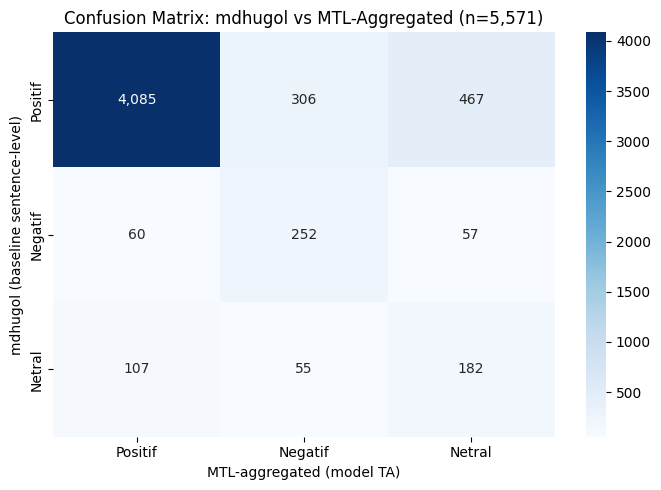

In [25]:
# 13.2 Confusion matrix mdhugol vs MTL-aggregated
# Hanya untuk subset yang punya span MTL.

from sklearn.metrics import confusion_matrix

overlap = out_df[out_df['mtl_review_sentiment'] != 'Tidak Ada Span'].copy()
labels = ['Positif', 'Negatif', 'Netral']
cm = confusion_matrix(overlap['sentiment'], overlap['mtl_review_sentiment'], labels=labels)

agree = (overlap['sentiment'] == overlap['mtl_review_sentiment']).sum()
print(f'Subset overlap         : {len(overlap):,} review')
print(f'Agreement (sama label) : {agree:,} ({agree/len(overlap)*100:.2f}%)')
print(f'Disagreement           : {len(overlap)-agree:,} ({(len(overlap)-agree)/len(overlap)*100:.2f}%)')

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, cbar=True)
plt.xlabel('MTL-aggregated (model TA)')
plt.ylabel('mdhugol (baseline sentence-level)')
plt.title(f'Confusion Matrix: mdhugol vs MTL-Aggregated (n={len(overlap):,})')
plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(OUT_PATH), 'confusion_mdhugol_vs_mtl.png'),
            dpi=120, bbox_inches='tight')
plt.show()


In [26]:
# 13.3 Studi kasus disagreement (jawab Q5: review yang labelnya 'flip')
disagree = out_df[
    (out_df['mtl_review_sentiment'] != 'Tidak Ada Span') &
    (out_df['mtl_review_sentiment'] != out_df['sentiment'])
].copy()

print(f'Total disagreement: {len(disagree):,} review')
print('Breakdown per pasangan label (mdhugol -> MTL):')
pair_counts = disagree.groupby(['sentiment', 'mtl_review_sentiment']).size().sort_values(ascending=False)
print(pair_counts.to_string())

print('\n=== Contoh konkret per pasangan (top 3 per pair) ===')
for (mdh, mtl), group in disagree.groupby(['sentiment', 'mtl_review_sentiment']):
    print(f'\n--- mdhugol: {mdh}  ->  MTL: {mtl}  ({len(group)} review) ---')
    for _, r in group.head(3).iterrows():
        review_text = str(r['review'])[:140]
        print(f'  - "{review_text}"')
        print(f'    spans MTL: {r["mtl_sentiments"]}')


Total disagreement: 1,052 review
Breakdown per pasangan label (mdhugol -> MTL):
sentiment  mtl_review_sentiment
Positif    Netral                  467
           Negatif                 306
Netral     Positif                 107
Negatif    Positif                  60
           Netral                   57
Netral     Negatif                  55

=== Contoh konkret per pasangan (top 3 per pair) ===

--- mdhugol: Negatif  ->  MTL: Netral  (57 review) ---
  - "ekowisata kampung blekok di dusun pesisir, desa klatakan, kecamatan kendit, situbondo, jawa timur, sudah menjadi rujukan wisatawan. setiap h"
    spans MTL: {'Akses & Lokasi': 'Netral'}
  - "wisata pantai dengan nuansa pohon mangrove, ada tempat selfi, ada warung, tapi jauh dari toilet. ."
    spans MTL: {'Pemandangan & Alam': 'Netral'}
  - "wisata alam yang penuh dengan blekok"
    spans MTL: {'Pemandangan & Alam': 'Netral'}

--- mdhugol: Negatif  ->  MTL: Positif  (60 review) ---
  - "bagus jalannya tapi jauh"
    spans MTL: {'Akse

In [27]:
# 13.3b Breakdown mekanisme agregator pada flip Positif <-> Negatif
# Untuk 306 (mdhugol Positif -> MTL Negatif) dan 60 (mdhugol Negatif -> MTL Positif),
# pisahkan berdasarkan mekanisme aggregator: single span, dominasi mayoritas, atau tie-break.

from collections import Counter

def breakdown_mechanism(mtl_dict):
    """Klasifikasi mekanisme yang menentukan label akhir.
    Returns: 'single_span' | 'clear_majority' | 'tie_pos_neg'
             | 'tie_neg_neu' | 'tie_pos_neu' | 'tie_three_way'
    """
    if not isinstance(mtl_dict, dict) or not mtl_dict:
        return 'no_span'
    counts = Counter(mtl_dict.values())
    n_pos = counts.get('Positif', 0)
    n_neg = counts.get('Negatif', 0)
    n_neu = counts.get('Netral', 0)
    total = n_pos + n_neg + n_neu
    if total == 1:
        return 'single_span'
    max_c = max(n_pos, n_neg, n_neu)
    winners = {s for s, c in [('Positif', n_pos), ('Negatif', n_neg), ('Netral', n_neu)] if c == max_c}
    if len(winners) == 1:
        return 'clear_majority'
    if winners == {'Positif', 'Negatif', 'Netral'}:
        return 'tie_three_way'
    if winners == {'Positif', 'Negatif'}:
        return 'tie_pos_neg'
    if winners == {'Negatif', 'Netral'}:
        return 'tie_neg_neu'
    if winners == {'Positif', 'Netral'}:
        return 'tie_pos_neu'
    return 'other'


def span_signature(mtl_dict):
    if not isinstance(mtl_dict, dict):
        return 'no_span'
    c = Counter(mtl_dict.values())
    return f"NEG={c.get('Negatif',0)} POS={c.get('Positif',0)} NEU={c.get('Netral',0)}"


flip_p2n = out_df[
    (out_df['sentiment'] == 'Positif') &
    (out_df['mtl_review_sentiment'] == 'Negatif')
].copy()
flip_n2p = out_df[
    (out_df['sentiment'] == 'Negatif') &
    (out_df['mtl_review_sentiment'] == 'Positif')
].copy()

flip_p2n['mechanism'] = flip_p2n['mtl_sentiments'].apply(breakdown_mechanism)
flip_n2p['mechanism'] = flip_n2p['mtl_sentiments'].apply(breakdown_mechanism)

print(f'=== Breakdown Positif -> Negatif (n={len(flip_p2n)}) ===')
mech_p2n = flip_p2n['mechanism'].value_counts()
for mech, cnt in mech_p2n.items():
    pct = cnt / len(flip_p2n) * 100
    print(f'  {mech:20s}: {cnt:>4d} ({pct:5.1f}%)')

print(f'\n  Top 10 komposisi span pada Positif -> Negatif:')
print(flip_p2n['mtl_sentiments'].apply(span_signature).value_counts().head(10).to_string())

print(f'\n=== Breakdown Negatif -> Positif (n={len(flip_n2p)}) ===')
mech_n2p = flip_n2p['mechanism'].value_counts()
for mech, cnt in mech_n2p.items():
    pct = cnt / len(flip_n2p) * 100
    print(f'  {mech:20s}: {cnt:>4d} ({pct:5.1f}%)')

print(f'\n  Top 10 komposisi span pada Negatif -> Positif:')
print(flip_n2p['mtl_sentiments'].apply(span_signature).value_counts().head(10).to_string())


=== Breakdown Positif -> Negatif (n=306) ===
  single_span         :  161 ( 52.6%)
  tie_pos_neg         :   88 ( 28.8%)
  clear_majority      :   27 (  8.8%)
  tie_neg_neu         :   21 (  6.9%)
  tie_three_way       :    9 (  2.9%)

  Top 10 komposisi span pada Positif -> Negatif:
mtl_sentiments
NEG=1 POS=0 NEU=0    161
NEG=1 POS=1 NEU=0     84
NEG=1 POS=0 NEU=1     21
NEG=2 POS=0 NEU=0     13
NEG=1 POS=1 NEU=1      9
NEG=2 POS=1 NEU=0      9
NEG=3 POS=0 NEU=0      3
NEG=2 POS=2 NEU=0      3
NEG=2 POS=0 NEU=1      2
NEG=2 POS=2 NEU=1      1

=== Breakdown Negatif -> Positif (n=60) ===
  single_span         :   48 ( 80.0%)
  clear_majority      :    8 ( 13.3%)
  tie_pos_neu         :    4 (  6.7%)

  Top 10 komposisi span pada Negatif -> Positif:
mtl_sentiments
NEG=0 POS=1 NEU=0    48
NEG=0 POS=1 NEU=1     4
NEG=0 POS=2 NEU=0     4
NEG=1 POS=2 NEU=0     2
NEG=0 POS=3 NEU=0     1
NEG=0 POS=2 NEU=1     1


In [28]:
# 13.4 Per-aspek: berapa pair (review, aspek) yang labelnya 'jatuh' kalau fallback dimatikan
exploded = out_df.explode('aspects').copy()
exploded = exploded[exploded['aspects'] != 'Lainnya']
exploded['has_mtl_span']    = exploded.apply(lambda r: r['aspects'] in r['mtl_sentiments'], axis=1)
exploded['hybrid_sentiment'] = exploded.apply(
    lambda r: r['mtl_sentiments'].get(r['aspects'], r['sentiment']), axis=1)

per_aspect = exploded.groupby('aspects').agg(
    total=('hybrid_sentiment', 'size'),
    pair_with_mtl=('has_mtl_span', 'sum'),
)
per_aspect['pair_drop_if_no_fallback'] = per_aspect['total'] - per_aspect['pair_with_mtl']
per_aspect['mtl_coverage_pct']         = (per_aspect['pair_with_mtl'] / per_aspect['total'] * 100).round(1)
per_aspect = per_aspect.sort_values('total', ascending=False)
print('=== Per-Aspek: Cakupan MTL (pair-level) ===')
print(per_aspect.to_string())

print(f"\nTotal pair (review, aspek) non-Lainnya: {len(exploded):,}")
print(f"Pair pakai MTL                         : {exploded['has_mtl_span'].sum():,} "
      f"({exploded['has_mtl_span'].mean()*100:.1f}%)")
print(f"Pair pakai fallback ke mdhugol         : {(~exploded['has_mtl_span']).sum():,} "
      f"({(~exploded['has_mtl_span']).mean()*100:.1f}%)")


=== Per-Aspek: Cakupan MTL (pair-level) ===
                    total  pair_with_mtl  pair_drop_if_no_fallback  mtl_coverage_pct
aspects                                                                             
Suasana              3454            860                      2594              24.9
Pemandangan & Alam   2832           1573                      1259              55.5
Kebersihan           2627            325                      2302              12.4
Harga & Tiket        1880            876                      1004              46.6
Budaya & Tradisi     1746            662                      1084              37.9
Kuliner              1742            707                      1035              40.6
Pelayanan            1639            579                      1060              35.3
Fasilitas            1605           1179                       426              73.5
Akses & Lokasi       1483            715                       768              48.2

Total pair (review, 

### 13.5 Generate Berkas Paralel untuk Dashboard Mode MTL-Only

Lima berkas berikut menjadi sumber data untuk dashboard ketika dijalankan dengan flag `--mtl-only`. Strukturnya identik dengan file default sehingga `app.py` cukup melakukan path-swap:

| File default | File MTL-only | Beda |
|---|---|---|
| `sentiment_labeled.csv` | `sentiment_labeled_mtl_only.csv` | sentimen = MTL-aggregated; baris tanpa span dibuang; aspek = hanya kategori yang punya span MTL |
| `aspect_summary.json` | `aspect_summary_mtl_only.json` | dihitung dari pair MTL saja (no fallback) |
| `tfidf_keywords.json` | `tfidf_keywords_mtl_only.json` | grouping pakai `mtl_review_sentiment` |
| `opinion_words.json` | `opinion_words_mtl_only.json` | mask aspek pakai keys MTL |
| `insights_summary.json` | `insights_summary_mtl_only.json` | turunan dari aspect_summary_mtl_only & tfidf_mtl_only |


In [29]:
# 13.5a sentiment_labeled_mtl_only.csv
df_mtl = out_df[out_df['mtl_review_sentiment'] != 'Tidak Ada Span'].copy()

df_mtl['sentiment'] = df_mtl['mtl_review_sentiment']
df_mtl['aspects_mtl'] = df_mtl['mtl_sentiments'].apply(lambda d: sorted(d.keys()) if d else [])
df_mtl['aspects_str'] = df_mtl['aspects_mtl'].apply(lambda lst: '|'.join(lst) if lst else 'Lainnya')

# Per-aspect sentiment parallel ke aspects_str. Di mode MTL-only ini selalu
# diisi dari mtl_sentiments (tidak ada fallback) karena baris tanpa span MTL
# sudah dibuang di filter di atas.
df_mtl['aspect_sentiments_str'] = df_mtl.apply(
    lambda r: '|'.join([r['mtl_sentiments'].get(a, r['sentiment'])
                        for a in r['aspects_mtl']]),
    axis=1)

out_cols_mtl = ['review', 'cleaned_review', 'cleaned_review_stemmed',
                'label', 'sentiment', 'label_source', 'conf_score',
                'nama desa wisata', 'aspects_str',
                'aspect_sentiments_str']
out_cols_mtl = [c for c in out_cols_mtl if c in df_mtl.columns]

SENT_TO_LABEL = {'Positif': 1, 'Negatif': 0, 'Netral': 2}
df_mtl['label'] = df_mtl['sentiment'].map(SENT_TO_LABEL)
df_mtl['label_source'] = 'mtl_only'

OUT_PATH_MTL = os.path.join(os.path.dirname(OUT_PATH), 'sentiment_labeled_mtl_only.csv')
df_mtl[out_cols_mtl].to_csv(OUT_PATH_MTL, index=False, encoding='utf-8')
print(f'Saved {len(df_mtl):,} rows -> {OUT_PATH_MTL}')
print(f'(Default file: {len(out_df):,} rows. MTL-only mempertahankan {len(df_mtl)/len(out_df)*100:.1f}%)')
print('\nDistribusi sentimen MTL-only:')
print(df_mtl['sentiment'].value_counts())


Saved 5,571 rows -> d:\Kuliah\TA\TA_Notebook\sentiment analysis\data\sentiment_labeled_mtl_only.csv
(Default file: 13,278 rows. MTL-only mempertahankan 42.0%)

Distribusi sentimen MTL-only:
sentiment
Positif    4252
Netral      706
Negatif     613
Name: count, dtype: int64


In [30]:
# 13.5b aspect_summary_mtl_only.json
aspect_summary_mtl = {}
exp_mtl = df_mtl.explode('aspects_mtl').copy()
exp_mtl = exp_mtl[exp_mtl['aspects_mtl'].notna() & (exp_mtl['aspects_mtl'] != '')]
exp_mtl['mtl_pair_sentiment'] = exp_mtl.apply(
    lambda r: r['mtl_sentiments'].get(r['aspects_mtl'], None), axis=1)
exp_mtl = exp_mtl[exp_mtl['mtl_pair_sentiment'].notna()]

desa_list_mtl = sorted(df_mtl['nama desa wisata'].dropna().unique().tolist())

for desa in desa_list_mtl + ['Semua']:
    if desa == 'Semua':
        sub = exp_mtl
    else:
        sub = exp_mtl[exp_mtl['nama desa wisata'] == desa]

    desa_data = {}
    for aspect in list(ASPECT_KEYWORDS.keys()):
        asp_sub = sub[sub['aspects_mtl'] == aspect]
        if len(asp_sub) == 0:
            continue
        sc = asp_sub['mtl_pair_sentiment'].value_counts().to_dict()
        total_a = len(asp_sub)
        desa_data[aspect] = {
            'total':   total_a,
            'Positif': int(sc.get('Positif', 0)),
            'Negatif': int(sc.get('Negatif', 0)),
            'Netral':  int(sc.get('Netral',  0)),
            'positivity_rate': round(sc.get('Positif', 0) / total_a * 100, 1) if total_a > 0 else 0,
        }
    aspect_summary_mtl[desa] = desa_data

asp_path_mtl = os.path.join(os.path.dirname(OUT_PATH), 'aspect_summary_mtl_only.json')
with open(asp_path_mtl, 'w', encoding='utf-8') as f:
    _json.dump(aspect_summary_mtl, f, ensure_ascii=False, indent=2)
print(f'Saved -> {asp_path_mtl}')

print('\n=== Aspect summary (MTL-only) - Semua Desa ===')
for asp, data in sorted(aspect_summary_mtl['Semua'].items(), key=lambda x: x[1]['total'], reverse=True):
    print(f"  {asp:25s}  total={data['total']:>5,}  pos={data['Positif']:>4,}  "
          f"neg={data['Negatif']:>4,}  pos_rate={data['positivity_rate']:>5.1f}%")


Saved -> d:\Kuliah\TA\TA_Notebook\sentiment analysis\data\aspect_summary_mtl_only.json

=== Aspect summary (MTL-only) - Semua Desa ===
  Pemandangan & Alam         total=1,573  pos=1,376  neg=  67  pos_rate= 87.5%
  Fasilitas                  total=1,179  pos= 740  neg= 184  pos_rate= 62.8%
  Harga & Tiket              total=  876  pos= 541  neg=  93  pos_rate= 61.8%
  Suasana                    total=  860  pos= 806  neg=  15  pos_rate= 93.7%
  Akses & Lokasi             total=  715  pos= 364  neg= 203  pos_rate= 50.9%
  Kuliner                    total=  707  pos= 566  neg=  65  pos_rate= 80.1%
  Budaya & Tradisi           total=  662  pos= 510  neg=  12  pos_rate= 77.0%
  Pelayanan                  total=  579  pos= 506  neg=  30  pos_rate= 87.4%
  Kebersihan                 total=  325  pos= 192  neg=  84  pos_rate= 59.1%


In [31]:
# 13.5c tfidf_keywords_mtl_only.json
TFIDF_COL_MTL = ('cleaned_review_stemmed' if 'cleaned_review_stemmed' in df_mtl.columns
                 else 'cleaned_review')
tfidf_results_mtl = {}

for desa in desa_list_mtl + ['Semua']:
    for sentiment in ['Positif', 'Negatif', 'Netral']:
        if desa == 'Semua':
            subset = df_mtl[df_mtl['sentiment'] == sentiment]
        else:
            subset = df_mtl[(df_mtl['nama desa wisata'] == desa) & (df_mtl['sentiment'] == sentiment)]

        texts = subset[TFIDF_COL_MTL].dropna().tolist()
        if len(texts) < 5:
            continue

        try:
            tfidf = TfidfVectorizer(
                max_features=500,
                stop_words=list(STOPWORDS_ID),
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
            )
            X = tfidf.fit_transform(texts)
            mean_scores = X.mean(axis=0).A1
            top_idx = mean_scores.argsort()[::-1][:15]
            features = tfidf.get_feature_names_out()
            tfidf_results_mtl[f'{desa}_{sentiment}'] = [
                [features[i], round(float(mean_scores[i]), 4)] for i in top_idx
            ]
        except ValueError:
            continue

tfidf_path_mtl = os.path.join(os.path.dirname(OUT_PATH), 'tfidf_keywords_mtl_only.json')
with open(tfidf_path_mtl, 'w', encoding='utf-8') as f:
    _json.dump(tfidf_results_mtl, f, ensure_ascii=False, indent=2)
print(f'Saved -> {tfidf_path_mtl}  ({len(tfidf_results_mtl)} kombinasi desa x sentimen)')


Saved -> d:\Kuliah\TA\TA_Notebook\sentiment analysis\data\tfidf_keywords_mtl_only.json  (87 kombinasi desa x sentimen)


In [32]:
# 13.5d opinion_words_mtl_only.json
OPINION_COL_MTL = ('cleaned_review_stemmed' if 'cleaned_review_stemmed' in df_mtl.columns
                   else 'cleaned_review')

def get_opinion_words_mtl(df_subset, aspect, sentiment, stopwords, top_n=10):
    """Filter pakai sentimen *per-aspek* dari mtl_sentiments, bukan overall
    review sentiment. Cara lama menarik review yang aspek lain-nya negatif
    sebagai 'negatif' untuk aspek `aspect` ini."""
    def _aspect_sent(row):
        aspects = row['aspects_mtl']
        if not aspects or aspect not in aspects:
            return None
        return row['mtl_sentiments'].get(aspect, row['sentiment'])
    mask = df_subset.apply(_aspect_sent, axis=1) == sentiment
    texts = df_subset.loc[mask, OPINION_COL_MTL].dropna().tolist()
    words = []
    for t in texts:
        for w in str(t).lower().split():
            w = re.sub(r'[^a-z]', '', w)
            if len(w) > 2 and w not in stopwords:
                words.append(w)
    return [w for w, _ in Counter(words).most_common(top_n)]

opinion_data_mtl = {}
for desa in desa_list_mtl + ['Semua']:
    if desa == 'Semua':
        sub = df_mtl
    else:
        sub = df_mtl[df_mtl['nama desa wisata'] == desa]

    desa_op = {}
    for aspect in list(ASPECT_KEYWORDS.keys()):
        asp_op = {}
        for sentiment in ['Positif', 'Negatif', 'Netral']:
            words = get_opinion_words_mtl(sub, aspect, sentiment, STOPWORDS_ID, 10)
            if words:
                asp_op[sentiment] = words
        if asp_op:
            desa_op[aspect] = asp_op
    opinion_data_mtl[desa] = desa_op

op_path_mtl = os.path.join(os.path.dirname(OUT_PATH), 'opinion_words_mtl_only.json')
with open(op_path_mtl, 'w', encoding='utf-8') as f:
    _json.dump(opinion_data_mtl, f, ensure_ascii=False, indent=2)
print(f'Saved -> {op_path_mtl}')


Saved -> d:\Kuliah\TA\TA_Notebook\sentiment analysis\data\opinion_words_mtl_only.json


In [33]:
# 13.5e insights_summary_mtl_only.json
insights_mtl = {}
for desa in desa_list_mtl + ['Semua']:
    if desa == 'Semua':
        sub = df_mtl
    else:
        sub = df_mtl[df_mtl['nama desa wisata'] == desa]

    total_d = len(sub)
    if total_d == 0:
        continue

    sent_pct = {s: round((sub['sentiment'] == s).sum() / total_d * 100, 1)
                for s in ['Positif', 'Negatif', 'Netral']}

    asp_data = aspect_summary_mtl.get(desa, {})
    praised_sorted = sorted([(k, v) for k, v in asp_data.items()],
                            key=lambda x: x[1].get('Positif', 0), reverse=True)
    top_praised = []
    for asp_name, asp_vals in praised_sorted[:3]:
        if asp_vals.get('Positif', 0) > 0:
            opinions = get_opinion_words_mtl(sub, asp_name, 'Positif', STOPWORDS_ID, 5)
            top_praised.append({'category': asp_name, 'count': asp_vals['Positif'], 'opinions': opinions})

    crit_sorted = sorted([(k, v) for k, v in asp_data.items()],
                         key=lambda x: x[1].get('Negatif', 0), reverse=True)
    top_criticized = []
    for asp_name, asp_vals in crit_sorted[:3]:
        if asp_vals.get('Negatif', 0) > 0:
            opinions = get_opinion_words_mtl(sub, asp_name, 'Negatif', STOPWORDS_ID, 5)
            top_criticized.append({'category': asp_name, 'count': asp_vals['Negatif'], 'opinions': opinions})

    distinctive = [w for w, _ in tfidf_results_mtl.get(f'{desa}_Positif', [])[:5]]

    headline_pos = ''
    if top_praised:
        cats = ' dan '.join([p['category'] for p in top_praised[:2]])
        headline_pos = f'Pengunjung memuji {cats}'
    headline_neg = ''
    if top_criticized:
        cats = ' dan '.join([c['category'] for c in top_criticized[:2]])
        headline_neg = f'Keluhan utama terkait {cats}'

    insights_mtl[desa] = {
        'total_reviews': total_d,
        'sentiment_pct': sent_pct,
        'top_praised': top_praised,
        'top_criticized': top_criticized,
        'distinctive_keywords': distinctive,
        'headline_positive': headline_pos,
        'headline_negative': headline_neg,
    }

ins_path_mtl = os.path.join(os.path.dirname(OUT_PATH), 'insights_summary_mtl_only.json')
with open(ins_path_mtl, 'w', encoding='utf-8') as f:
    _json.dump(insights_mtl, f, ensure_ascii=False, indent=2)
print(f'Saved -> {ins_path_mtl}')

print('\n=== Insight (MTL-only) - Semua ===')
ins = insights_mtl.get('Semua', {})
print(f'Total review : {ins.get("total_reviews", 0):,}')
print(f'Sentiment pct: {ins.get("sentiment_pct", {})}')
print(f'Headline (+) : {ins.get("headline_positive", "")}')
print(f'Headline (-) : {ins.get("headline_negative", "")}')


Saved -> d:\Kuliah\TA\TA_Notebook\sentiment analysis\data\insights_summary_mtl_only.json

=== Insight (MTL-only) - Semua ===
Total review : 5,571
Sentiment pct: {'Positif': np.float64(76.3), 'Negatif': np.float64(11.0), 'Netral': np.float64(12.7)}
Headline (+) : Pengunjung memuji Pemandangan & Alam dan Suasana
Headline (-) : Keluhan utama terkait Akses & Lokasi dan Fasilitas


### 13.6 Ringkasan untuk Skripsi (Bab 4.7.10)

Section ini siap dikutip di Bab 4.7.10. Angka-angka kunci dari output cell di atas:

- **Coverage MTL-only**: lihat output 13.1 → ganti `(X)` di subsection draft.
- **Agreement rate**: lihat output 13.2 → ganti `(Y)` di subsection draft.
- **Top-3 pasangan disagreement**: lihat output 13.3.
- **Distribusi sentimen mode hibrida vs MTL-only**: bandingkan output 13.1 (atas) dengan 13.5a.
- **Cakupan per-aspek**: tabel 13.4.

**Verifikasi visual**: jalankan dashboard di dua port:

```
python app.py --port 8050              # mode hibrida (default)
python app.py --mtl-only --port 8051   # mode MTL-only (pakai berkas paralel)
```

Buka kedua URL berdampingan; perhatikan perbedaan distribusi sentimen di pie chart, jumlah baris di tabel ulasan, dan positivity rate di radar chart.

## 14. Word Cloud & Bigram Phrase-Based (Hybrid MTL + mdhugol)

Word cloud / bigram versi lama memakai **seluruh teks review** berdasar sentimen
*overall* → kata positif seperti "bagus" bocor ke cloud **negatif** (review
"pemandangan bagus tapi tiket mahal" overall-nya negatif tapi teksnya tetap memuat
"bagus").

Perbaikan **phrase-based**: tiap review dipecah jadi **klausa** (teks MENTAH, masih
punya koma + "tapi/namun"). Tiap klausa diberi sentimennya **sendiri**:

- klausa menyebut aspek yang ber-sentimen → pakai **sentimen per-aspek**
  (`aspect_sentiments_str` = MTL bila ada span, else overall) — presisi;
- selainnya → **mdhugol** (classifier level-kalimat) → coverage ~100%.

Lalu sebuah **filter polaritas** (rate dinormalisasi per kelas) membuang kata yang
sangat dominan di satu polaritas dari polaritas lain, untuk menutup sisa bocor dari
review *run-on* tanpa pemisah. Hasil per `(desa, sentimen)` → `phrase_words.json`
(+ `_mtl_only`) yang dibaca dashboard. Logika ini identik dengan `_build_phrase_words.py`.

In [ ]:
# ── 14. Word cloud & bigram PHRASE-BASED (hybrid MTL + mdhugol) ──
# Hasil: data/phrase_words.json (+ _mtl_only.json) untuk dashboard.
# Reuse objek notebook: _SLANG_DICT, _LIGHT_SW, _EMOJI, _stemmer (cell 6),
# ASPECT_KEYWORDS (cell 24), OUT_DIR/OUT_PATH (cell 2). Mirror _build_phrase_words.py.
import json as _json
from collections import Counter, defaultdict

_TOP_WORDS, _TOP_BIGRAMS = 120, 60
_DOM_FRAC, _MIN_TOTAL = 0.25, 10          # filter polaritas kata (rate per kelas)
_BG_RATIO = 2.5                           # filter bigram (rasio count mentah)


def _pw_norm_slang(text):
    return ' '.join(_SLANG_DICT.get(w, w) for w in text.split())


def _pw_clean(text):
    text = str(text).lower()
    text = _EMOJI.sub(' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = _pw_norm_slang(text)
    return ' '.join(w for w in text.split() if w not in _LIGHT_SW)


_pw_stem_cache = {}


def _pw_stem(w):
    s = _pw_stem_cache.get(w)
    if s is None:
        s = _stemmer.stem(w)
        _pw_stem_cache[w] = s
    return s


def _pw_words(clause):
    return [s for s in (_pw_stem(w) for w in _pw_clean(clause).split())
            if len(s) > 2 and s.isalpha()]


_PW_CONJ = ('tapi', 'namun', 'tetapi', 'cuma', 'cuman', 'sayang', 'sedangkan',
            'walaupun', 'walau', 'meskipun', 'meski', 'kecuali', 'hanya', 'selain')
_PW_SPLIT = re.compile(r'[.,;!?\n]+|\b(?:' + '|'.join(_PW_CONJ) + r')\b')


def _pw_segment(text):
    return [p.strip() for p in _PW_SPLIT.split(text) if p and p.strip()]


def _pw_cat(clause, amap):
    # Kategori aspek klausa; utamakan kategori yang ada di peta sentimen review.
    t = clause.lower()
    first = None
    for cat, kws in ASPECT_KEYWORDS.items():
        if any(kw in t for kw in kws):
            if cat in amap:
                return cat
            if first is None:
                first = cat
    return first


_PW_HFMAP = {'LABEL_0': 'Positif', 'LABEL_1': 'Netral', 'LABEL_2': 'Negatif'}


def _pw_suppress(semua):
    # Per sentimen, kata yang harus disembunyikan karena dominan di polaritas lain.
    sents = ('Positif', 'Negatif', 'Netral')
    tot = {s: (sum(semua[s].values()) or 1) for s in sents}
    allw = set().union(*[set(semua[s]) for s in sents]) if semua else set()
    sup = {s: set() for s in sents}
    for w in allw:
        cnt = {s: semua[s].get(w, 0) for s in sents}
        if sum(cnt.values()) < _MIN_TOTAL:
            continue
        rate = {s: cnt[s] / tot[s] for s in sents}
        peak = max(rate.values())
        if peak <= 0:
            continue
        for s in sents:
            if rate[s] < _DOM_FRAC * peak:
                sup[s].add(w)
    return sup


def _pw_bg_suppress(semua_bg):
    # Bigram disembunyikan dari sentimen s bila count-nya < peak/_BG_RATIO
    # (count mentah). Membuang frasa positif yang bocor ke negatif spt 'desa bersih'.
    sents = ('Positif', 'Negatif', 'Netral')
    allb = set().union(*[set(semua_bg[s]) for s in sents]) if semua_bg else set()
    sup = {s: set() for s in sents}
    for b in allb:
        cnt = {s: semua_bg[s].get(b, 0) for s in sents}
        peak = max(cnt.values())
        if peak <= 0:
            continue
        for s in sents:
            if cnt[s] * _BG_RATIO < peak:
                sup[s].add(b)
    return sup


def _pw_build(df, classifier):
    amaps = [dict(zip(a.split('|'), s.split('|')))
             for a, s in zip(df['aspects_str'].fillna(''), df['aspect_sentiments_str'].fillna(''))]
    records, need = [], []
    for desa, review, amap in zip(df['nama desa wisata'], df['review'].fillna(''), amaps):
        text = _pw_norm_slang(str(review).lower())
        for cl in _pw_segment(text):
            cat = _pw_cat(cl, amap)
            sent = amap.get(cat) if cat else None
            if sent not in ('Positif', 'Negatif', 'Netral'):
                sent = None
            records.append((desa, cl, sent))
            if sent is None and classifier is not None:
                need.append(cl)
    sbc = {}
    if classifier is not None and need:
        uniq = [c for c in dict.fromkeys(need) if c.strip()]
        preds = classifier(uniq, batch_size=64, truncation=True, max_length=128)
        sbc = {c: _PW_HFMAP[p['label']] for c, p in zip(uniq, preds)}
    wc = defaultdict(lambda: defaultdict(Counter))
    bc = defaultdict(lambda: defaultdict(Counter))
    for desa, cl, sent in records:
        if sent is None:
            sent = sbc.get(cl)
            if sent is None:
                continue
        ws = _pw_words(cl)
        if not ws:
            continue
        for d in (desa, 'Semua'):
            wc[d][sent].update(ws)
            bc[d][sent].update(f'{a} {b}' for a, b in zip(ws, ws[1:]))
    sup = _pw_suppress(wc['Semua'])
    bsup = _pw_bg_suppress(bc['Semua'])
    out = {}
    for desa in wc:
        out[desa] = {}
        for sent in ('Positif', 'Negatif', 'Netral'):
            su, bsu = sup[sent], bsup[sent]
            w = [(k, int(v)) for k, v in wc[desa][sent].most_common() if k not in su][:_TOP_WORDS]
            b = [(k, int(v)) for k, v in bc[desa][sent].most_common()
                 if k not in bsu and not (set(k.split()) & su)][:_TOP_BIGRAMS]
            if w or b:
                out[desa][sent] = {'words': [list(x) for x in w], 'bigrams': [list(x) for x in b]}
    return out


# Reload mdhugol (sudah di-free saat load MTL)
from transformers import (pipeline as _pl, AutoModelForSequenceClassification as _AM,
                          AutoTokenizer as _AT)
_pw_name = 'mdhugol/indonesia-bert-sentiment-classification'
_pw_clf = _pl('sentiment-analysis', model=_AM.from_pretrained(_pw_name),
              tokenizer=_AT.from_pretrained(_pw_name),
              device=0 if torch.cuda.is_available() else -1)

# Default (hybrid + fallback mdhugol)
_pw_out = _pw_build(pd.read_csv(OUT_PATH), _pw_clf)
with open(os.path.join(OUT_DIR, 'phrase_words.json'), 'w', encoding='utf-8') as f:
    _json.dump(_pw_out, f, ensure_ascii=False, indent=2)
print('Saved phrase_words.json:', len(_pw_out), 'desa keys')
print('  Semua/Negatif top:', [w for w, _ in _pw_out['Semua']['Negatif']['words'][:12]])
print("  'bagus' di cloud Negatif?", any(w == 'bagus' for w, _ in _pw_out['Semua']['Negatif']['words']))

# MTL-only (tanpa fallback mdhugol)
_pw_mtl = os.path.join(OUT_DIR, 'sentiment_labeled_mtl_only.csv')
if os.path.exists(_pw_mtl):
    _pw_out2 = _pw_build(pd.read_csv(_pw_mtl), None)
    with open(os.path.join(OUT_DIR, 'phrase_words_mtl_only.json'), 'w', encoding='utf-8') as f:
        _json.dump(_pw_out2, f, ensure_ascii=False, indent=2)
    print('Saved phrase_words_mtl_only.json:', len(_pw_out2), 'desa keys')

del _pw_clf
import gc as _gc
_gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('Done. mdhugol freed.')

In [ ]:
# ── 14b. Opinion words per-aspek (PER-KLAUSA) — supersede cell 10b/opinion ──
# Masalah lama get_opinion_words: ambil SEMUA kata dari teks review yang menyebut
# aspek -> (1) kata aspek lain bocor ('makan'@Kebersihan), (2) kata positif bocor
# ke daftar Negatif ('bagus'@keluhan). Solusi: kata hanya dari KLAUSA yang
# menyebut aspek (reuse _pw_segment/_pw_words/_pw_suppress dari cell 14), sentimen
# per-aspek dari data, + filter polaritas global. Mirror _build_opinion_words.py.
# Cell ini MENULIS ULANG opinion_words*.json & me-refresh field 'opinions' di
# insights_summary*.json yang dibuat cell-cell sebelumnya.
_OP_TOP, _INS_TOP = 10, 5
_OP_SENTS = ('Positif', 'Negatif', 'Netral')
_OP_GENERIC = {_pw_stem(w) for w in {
    'tempat', 'tempatnya', 'wisata', 'desa', 'lokasi', 'pergi', 'datang',
    'kunjungi', 'kunjungan', 'objek', 'destinasi', 'daerah', 'area', 'kawasan',
    'spot', 'kesini', 'kesana', 'main', 'liburan', 'kemarin', 'tadi',
    'sekarang', 'nanti', 'dulu', 'banyak', 'sedikit', 'sebagian', 'banget'}}


def _op_build(csv_path, op_out, ins_out):
    odf = pd.read_csv(csv_path)
    amaps = [dict(zip(a.split('|'), s.split('|')))
             for a, s in zip(odf['aspects_str'].fillna(''),
                             odf['aspect_sentiments_str'].fillna(''))]
    ctr = defaultdict(lambda: defaultdict(lambda: defaultdict(Counter)))
    gctr = {s: Counter() for s in _OP_SENTS}           # untuk filter polaritas global
    for desa, review, amap in zip(odf['nama desa wisata'],
                                  odf['review'].fillna(''), amaps):
        text = _pw_norm_slang(str(review).lower())
        for cl in _pw_segment(text):
            t = cl.lower()
            cats = [c for c, kws in ASPECT_KEYWORDS.items()
                    if c in amap and any(kw in t for kw in kws)]
            if not cats:
                continue
            ws = [w for w in _pw_words(cl) if w not in _OP_GENERIC]
            if not ws:
                continue
            for c in cats:
                sent = amap[c]
                if sent not in _OP_SENTS:
                    continue
                ctr[desa][c][sent].update(ws)
                ctr['Semua'][c][sent].update(ws)
                gctr[sent].update(ws)
    sup = _pw_suppress(gctr)
    op = {}
    for desa, aspects in ctr.items():
        d_out = {}
        for c, by_sent in aspects.items():
            a_out = {}
            for sent in _OP_SENTS:
                words = [w for w, _ in by_sent[sent].most_common()
                         if w not in sup[sent]][:_OP_TOP]
                if words:
                    a_out[sent] = words
            if a_out:
                d_out[c] = a_out
        op[desa] = d_out
    with open(op_out, 'w', encoding='utf-8') as f:
        _json.dump(op, f, ensure_ascii=False, indent=2)
    if os.path.exists(ins_out):
        with open(ins_out, encoding='utf-8') as f:
            ins = _json.load(f)
        for desa, blk in ins.items():
            od = op.get(desa, {})
            for p in blk.get('top_praised', []):
                p['opinions'] = od.get(p['category'], {}).get('Positif', [])[:_INS_TOP]
            for cc in blk.get('top_criticized', []):
                cc['opinions'] = od.get(cc['category'], {}).get('Negatif', [])[:_INS_TOP]
        with open(ins_out, 'w', encoding='utf-8') as f:
            _json.dump(ins, f, ensure_ascii=False, indent=2)
    return op


_op_def = _op_build(OUT_PATH,
                    os.path.join(OUT_DIR, 'opinion_words.json'),
                    os.path.join(OUT_DIR, 'insights_summary.json'))
print('Rebuilt opinion_words.json:', len(_op_def), 'desa keys')

_op_mtl_csv = os.path.join(OUT_DIR, 'sentiment_labeled_mtl_only.csv')
if os.path.exists(_op_mtl_csv):
    _op_build(_op_mtl_csv,
              os.path.join(OUT_DIR, 'opinion_words_mtl_only.json'),
              os.path.join(OUT_DIR, 'insights_summary_mtl_only.json'))
    print('Rebuilt opinion_words_mtl_only.json')

# Sanity: tidak ada kata lintas-aspek 'makan' di Pemandangan, & cek beberapa aspek
_sd = 'Pentingsari'
if _sd in _op_def:
    print(f"  {_sd} | Pemandangan & Alam (+):",
          _op_def[_sd].get('Pemandangan & Alam', {}).get('Positif', [])[:6])
    print(f"  {_sd} | Suasana (+):",
          _op_def[_sd].get('Suasana', {}).get('Positif', [])[:6])
